## **MDQ Project**
  - An end-to-end AI solution for discovering hidden commercial activity among physical persons using transaction analytics, clustering, and predictive modeling.

  Team name: The Ace of tech

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split #for model selection
from sklearn.preprocessing import StandardScaler #for feature scaling
from sklearn.ensemble import IsolationForest #for anomaly detection
from sklearn.svm import OneClassSVM #for anomaly detection
from scipy.stats import rankdata #for ranking the anomaly scores
from sklearn.metrics import classification_report, confusion_matrix #for evaluation
import warnings
warnings.filterwarnings('ignore') #to ignore warnings for cleaner output
from sklearn.metrics import roc_auc_score, roc_curve #for AUC-ROC evaluation

In [4]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"]      = True

In [5]:
business = pd.read_parquet("business_cards_MDQ.parquet")
consumer = pd.read_parquet("consumer_cards_MDQ.parquet")
merchants = pd.read_parquet("merchants_reference.parquet")

## EDA part

In [6]:
# размеры датасетов
print("Business shape:", business.shape)
print("Consumer shape:", consumer.shape)
print("Merchants shape:", merchants.shape)

Business shape: (2997593, 12)
Consumer shape: (9832487, 12)
Merchants shape: (2165, 5)


In [7]:
# просматриваем колонки и типы данных
print("Business columns:")
print(business.columns.tolist())
print(business.dtypes)
print(business.info())
print("\n")  # добавляем пустую строку для разделения вывода

print("\nConsumer columns:")
print(consumer.columns.tolist())
print(consumer.dtypes)
print(consumer.info())


print("\nMerchants columns:")
print(merchants.columns.tolist())
print(merchants.dtypes)
print(merchants.info())

Business columns:
['transaction_date', 'transaction_timestamp', 'transaction_amount_kzt', 'mcc', 'merchant_id', 'channel', 'bank_name', 'country', 'card_number', 'card_tier', 'tokenized', 'is_recurring']
transaction_date                  object
transaction_timestamp     datetime64[ms]
transaction_amount_kzt             int64
mcc                               object
merchant_id                       object
channel                           object
bank_name                         object
country                           object
card_number                       object
card_tier                         object
tokenized                           bool
is_recurring                        bool
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2997593 entries, 0 to 2997592
Data columns (total 12 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   transaction_date        object        
 1   transaction_timestamp   datetime64[ms]
 

#### Смотрим первые колонки\данные

In [8]:
business.head()


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
0,2025-10-01,2025-10-01 00:00:00,180976,7372,MER_000007,online,Kaspi,US,5228592291438845,Business,False,True
1,2025-10-01,2025-10-01 00:00:00,153206,7372,MER_000006,online,Home Credit Bank,US,5201495142193372,Business,False,True
2,2025-10-01,2025-10-01 00:00:00,197106,7372,MER_000007,online,Home Credit Bank,US,5201492177677288,Business,False,True
3,2025-10-01,2025-10-01 00:01:00,189598,7372,MER_000008,online,Kaspi,US,5176513443697635,Business,False,True
4,2025-10-01,2025-10-01 00:03:00,700571,7311,MER_000003,online,Halyk,Russia,5100611967455520,Business,False,True


In [9]:
consumer.head()

,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
0,2025-10-01,2025-10-01 00:04:00,4788,4814,MER_000064,online,Alatau City Bank,Kazakhstan,5263907968824596,Standard,False,True
1,2025-10-01,2025-10-01 00:10:00,5240,4814,MER_000063,online,Bank RBK,Kazakhstan,5119023663984986,Standard,False,True
2,2025-10-01,2025-10-01 00:12:00,4576,4814,MER_000066,online,Kaspi,Kazakhstan,5228590878155154,Standard,False,True
3,2025-10-01,2025-10-01 00:37:00,6078,4814,MER_000063,online,Home Credit Bank,Kazakhstan,5338472125333693,Standard,False,True
4,2025-10-01,2025-10-01 00:37:00,6042,4814,MER_000065,online,Kaspi,Kazakhstan,5531514712394557,Affluent,False,True


In [10]:
merchants.head()

,merchant_id,merchant_name,mcc,merchant_country,recurring_capable
0,MER_000000,Google Ads,7311,Ireland,True
1,MER_000001,Meta Ads,7311,Ireland,True
2,MER_000002,TikTok Ads,7311,Singapore,True
3,MER_000003,Yandex Direct,7311,Russia,True
4,MER_000004,LinkedIn Ads,7311,Ireland,True


In [11]:
business.isna().sum().sort_values(ascending=False) # проверяем пропуски в бизнес датасете

transaction_date          0
transaction_timestamp     0
transaction_amount_kzt    0
mcc                       0
merchant_id               0
channel                   0
bank_name                 0
country                   0
card_number               0
card_tier                 0
tokenized                 0
is_recurring              0
dtype: int64

In [12]:
consumer.isna().sum().sort_values(ascending=False) # проверяем пропуски в потребительском датасете

transaction_date          0
transaction_timestamp     0
transaction_amount_kzt    0
mcc                       0
merchant_id               0
channel                   0
bank_name                 0
country                   0
card_number               0
card_tier                 0
tokenized                 0
is_recurring              0
dtype: int64

In [13]:
merchants.isna().sum().sort_values(ascending=False) # проверяем пропуски в датасете с информацией о торговых точках

merchant_id          0
merchant_name        0
mcc                  0
merchant_country     0
recurring_capable    0
dtype: int64

In [14]:
# проверяем дупликаты в бизнес датасете
print("Business duplicates:", business.duplicated().sum())

Business duplicates: 0


In [15]:
# дупликаты в потребительском датасете
print("Consumer duplicates:", consumer.duplicated().sum())

Consumer duplicates: 0


In [16]:
# дупликаты в потребительском датасете
print("Consumer duplicates:", consumer.duplicated().sum())

Consumer duplicates: 0


In [17]:
business_df = pd.read_parquet('business_cards_MDQ.parquet')
consumer_df = pd.read_parquet('consumer_cards_MDQ.parquet')
merchants_ref = pd.read_parquet('merchants_reference.parquet')


In [18]:
print("Business info:")
business_df.info()

print("\nConsumer info:")
consumer_df.info()

Business info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2997593 entries, 0 to 2997592
Data columns (total 12 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   transaction_date        object        
 1   transaction_timestamp   datetime64[ms]
 2   transaction_amount_kzt  int64         
 3   mcc                     object        
 4   merchant_id             object        
 5   channel                 object        
 6   bank_name               object        
 7   country                 object        
 8   card_number             object        
 9   card_tier               object        
 10  tokenized               bool          
 11  is_recurring            bool          
dtypes: bool(2), datetime64[ms](1), int64(1), object(8)
memory usage: 234.4+ MB

Consumer info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9832487 entries, 0 to 9832486
Data columns (total 12 columns):
 #   Column                  Dtype         
---

In [19]:
def basic_overview(df, name):
    print(f"===== {name} =====")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Unique cards:", df['card_number'].nunique())
    
    if 'merchant_id' in df.columns:
        print("Unique merchants:", df['merchant_id'].nunique())
    
    print("\nMissing values:")
    display(df.isna().sum().sort_values(ascending=False).head(20))
    
    print("\nDuplicate rows:", df.duplicated().sum())

In [20]:
basic_overview(business_df, "Business Cards")
basic_overview(consumer_df, "Consumer Cards")

===== Business Cards =====
Rows: 2997593
Columns: 12
Unique cards: 25000
Unique merchants: 481

Missing values:


transaction_date          0
transaction_timestamp     0
transaction_amount_kzt    0
mcc                       0
merchant_id               0
channel                   0
bank_name                 0
country                   0
card_number               0
card_tier                 0
tokenized                 0
is_recurring              0
dtype: int64


Duplicate rows: 0
===== Consumer Cards =====
Rows: 9832487
Columns: 12
Unique cards: 80000
Unique merchants: 2060

Missing values:


transaction_date          0
transaction_timestamp     0
transaction_amount_kzt    0
mcc                       0
merchant_id               0
channel                   0
bank_name                 0
country                   0
card_number               0
card_tier                 0
tokenized                 0
is_recurring              0
dtype: int64


Duplicate rows: 0


Business accounts generated 3 million transactions across 25,000 cards, while consumer accounts generated nearly 10 million transactions across 80,000 cards. There are no missing values or duplicates — the data is already clean and does not require preprocessing.

An interesting insight: businesses transact with only 481 merchants out of 2,165 total merchants, whereas consumers interact with almost all of them (2,060). In other words, businesses operate within a narrow, specialized “merchant ecosystem,” while consumers spend more broadly across many different categories and merchants.

### **Transaction amount analysis**

In [21]:
amount_col = 'transaction_amount_kzt'  

business_df[amount_col].describe()

count    2.997593e+06
mean     1.565353e+05
std      2.528682e+05
min      6.700000e+01
25%      2.283500e+04
50%      7.722400e+04
75%      1.960810e+05
max      4.079930e+07
Name: transaction_amount_kzt, dtype: float64

In [22]:
consumer_df[amount_col].describe()

count    9.832487e+06
mean     5.404542e+04
std      1.696546e+05
min      1.500000e+01
25%      4.172000e+03
50%      1.189200e+04
75%      3.966500e+04
max      3.197103e+07
Name: transaction_amount_kzt, dtype: float64

In [23]:
def plot_amount_distribution(df, name, amount_col):
    plt.figure(figsize=(10, 5))
    df[amount_col].clip(upper=df[amount_col].quantile(0.99)).hist(bins=50)
    plt.title(f'{name}: Transaction Amount Distribution')
    plt.xlabel('Transaction amount')
    plt.ylabel('Frequency')
    plt.show()

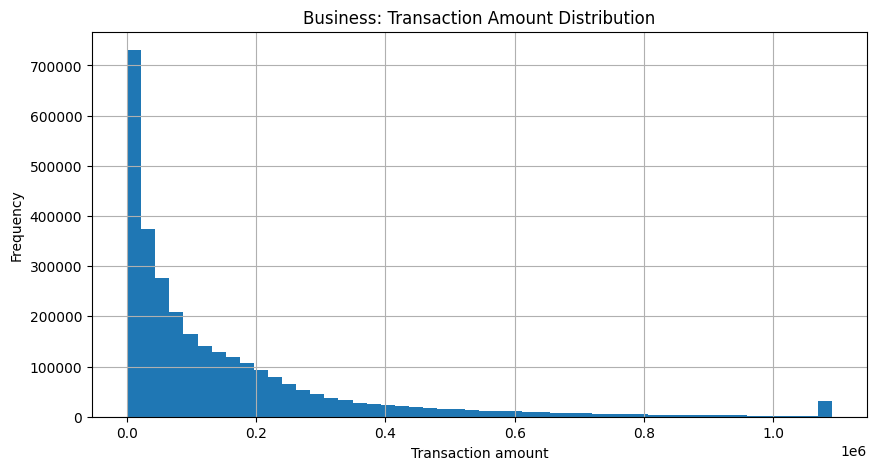

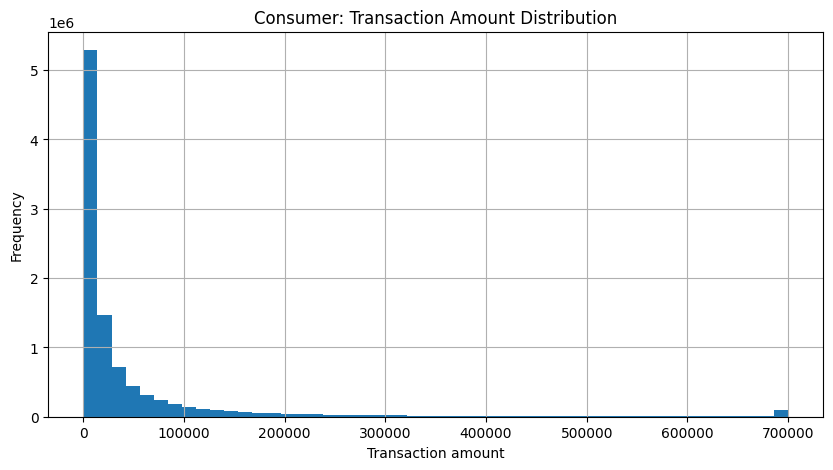

In [24]:
plot_amount_distribution(business_df, "Business", amount_col)
plot_amount_distribution(consumer_df, "Consumer", amount_col)

In [25]:
def card_amount_features(df, amount_col):
    return df.groupby('card_number').agg(
        total_amount=(amount_col, 'sum'),
        mean_amount=(amount_col, 'mean'),
        median_amount=(amount_col, 'median'),
        std_amount=(amount_col, 'std'),
        max_amount=(amount_col, 'max'),
        min_amount=(amount_col, 'min'),
        transaction_count=(amount_col, 'count')
    ).reset_index()

In [26]:
business_amount_card = card_amount_features(business_df, amount_col)
consumer_amount_card = card_amount_features(consumer_df, amount_col)

display(business_amount_card.head())
display(consumer_amount_card.head())

,card_number,total_amount,mean_amount,median_amount,std_amount,max_amount,min_amount,transaction_count
0,5100610003025081,9651486,54221.831461,14499.0,92378.778008,745914,659,178
1,5100610003044611,14353608,135411.396226,67810.0,198947.026012,1483178,604,106
2,5100610003860784,13102356,88529.432432,56445.0,101798.906783,652796,262,148
3,5100610008756482,27341119,139495.505102,98362.5,163409.474324,1286163,1208,196
4,5100610013466473,16439793,136998.275000,46989.0,185183.080133,982511,326,120


,card_number,total_amount,mean_amount,median_amount,std_amount,max_amount,min_amount,transaction_count
0,5100610005930965,14215001,330581.418605,168999.0,457017.109755,2137325,4410,43
1,5100610005962109,1303168,10950.991597,5886.0,23120.959998,223504,347,119
2,5100610007285137,1202801,12529.177083,4803.0,23919.649464,190489,396,96
3,5100610011916156,2916033,19184.427632,9465.5,37685.428473,404648,688,152
4,5100610012043588,1796507,28975.919355,11653.0,56269.532103,342115,197,62


In [27]:
business_amount_card.describe()

,total_amount,mean_amount,median_amount,std_amount,max_amount,min_amount,transaction_count
count,2.500000e+04,25000.000000,25000.000000,2.500000e+04,2.500000e+04,25000.000000,25000.000000
mean,1.876916e+07,167642.447808,92225.245400,2.301465e+05,1.494760e+06,1810.038080,119.903720
std,6.897553e+06,64423.261719,50852.489384,1.110944e+05,1.125650e+06,2718.911361,43.044349
min,2.615035e+06,26838.925466,2116.000000,4.502473e+04,2.076620e+05,67.000000,26.000000
25%,1.363701e+07,125838.931548,59458.625000,1.635633e+05,8.624258e+05,670.000000,84.000000
50%,1.771489e+07,155609.899373,84558.500000,2.044494e+05,1.204462e+06,1080.000000,119.000000
75%,2.288589e+07,193926.926776,115733.375000,2.633677e+05,1.761576e+06,1876.250000,155.000000
max,6.435703e+07,776261.333333,612595.500000,3.291898e+06,4.079930e+07,64365.000000,242.000000


In [28]:
consumer_amount_card.describe()

,total_amount,mean_amount,median_amount,std_amount,max_amount,min_amount,transaction_count
count,8.000000e+04,8.000000e+04,8.000000e+04,8.000000e+04,8.000000e+04,80000.000000,80000.000000
mean,6.642512e+06,5.477014e+04,2.311945e+04,9.997246e+04,7.364325e+05,1095.116788,122.906087
std,8.606655e+06,7.123950e+04,3.785588e+04,1.205720e+05,9.500055e+05,1899.347055,47.978862
min,3.452870e+05,5.446994e+03,2.134000e+03,5.798632e+03,2.435200e+04,15.000000,17.000000
25%,1.966989e+06,1.714747e+04,5.919000e+03,3.186985e+04,2.096278e+05,371.000000,85.000000
50%,2.976294e+06,2.677495e+04,9.673500e+03,5.290767e+04,3.731065e+05,576.000000,120.000000
75%,6.259916e+06,6.356528e+04,2.638900e+04,1.154282e+05,8.548310e+05,1256.000000,156.000000
max,1.701590e+08,2.215910e+06,1.520916e+06,2.547872e+06,3.197103e+07,285067.000000,354.000000


### Transaction Amounts 

Businesses tend to spend much larger amounts per transaction. A typical business transaction is around 77,000 KZT, while for consumers it is approximately 12,000 KZT.

The difference is significant:

* the median transaction amount is 6.5 times higher for businesses;
* the mean transaction amount is almost 3 times higher.

The fact that the gap in averages is smaller than the gap in medians suggests that consumers occasionally make rare high-value purchases, which pull the average upward.

### **Card activity analysis**

In [29]:
date_col = 'transaction_date'  

business_df[date_col] = pd.to_datetime(business_df[date_col])
consumer_df[date_col] = pd.to_datetime(consumer_df[date_col])

In [30]:
def activity_features(df, date_col):
    temp = df.copy()
    temp[date_col] = pd.to_datetime(temp[date_col], errors='coerce')
    
    temp = temp.dropna(subset=[date_col])
    
    temp['transaction_day'] = temp[date_col].dt.date
    
    features = temp.groupby('card_number').agg(
        first_transaction=(date_col, 'min'),
        last_transaction=(date_col, 'max'),
        active_days=('transaction_day', 'nunique'),
        transaction_count=(date_col, 'count')
    ).reset_index()
    
    features['period_days'] = (
        features['last_transaction'] - features['first_transaction']
    ).dt.days + 1
    
    features['transactions_per_active_day'] = (
        features['transaction_count'] / features['active_days']
    )
    
    features['transactions_per_period_day'] = (
        features['transaction_count'] / features['period_days']
    )
    
    return features

In [31]:
business_activity = activity_features(business_df, date_col)
consumer_activity = activity_features(consumer_df, date_col)

display(business_activity.head())
display(consumer_activity.head())

,card_number,first_transaction,last_transaction,active_days,transaction_count,period_days,transactions_per_active_day,transactions_per_period_day
0,5100610003025081,2025-10-01,2026-03-31,105,178,182,1.695238,0.978022
1,5100610003044611,2025-10-01,2026-03-31,80,106,182,1.325000,0.582418
2,5100610003860784,2025-10-01,2026-03-31,90,148,182,1.644444,0.813187
3,5100610008756482,2025-10-01,2026-03-30,101,196,181,1.940594,1.082873
4,5100610013466473,2025-10-03,2026-03-31,80,120,180,1.500000,0.666667


,card_number,first_transaction,last_transaction,active_days,transaction_count,period_days,transactions_per_active_day,transactions_per_period_day
0,5100610005930965,2025-10-02,2026-03-31,40,43,181,1.075000,0.237569
1,5100610005962109,2025-10-02,2026-03-31,82,119,181,1.451220,0.657459
2,5100610007285137,2025-10-04,2026-03-28,73,96,176,1.315068,0.545455
3,5100610011916156,2025-10-02,2026-03-30,91,152,180,1.670330,0.844444
4,5100610012043588,2025-10-01,2026-03-30,49,62,181,1.265306,0.342541


In [32]:
def plot_card_feature_distribution(business_feat, consumer_feat, feature):
    plt.figure(figsize=(10, 5))
    
    business_feat[feature].clip(
        upper=business_feat[feature].quantile(0.99)
    ).hist(bins=50, alpha=0.6, label='Business')
    
    consumer_feat[feature].clip(
        upper=consumer_feat[feature].quantile(0.99)
    ).hist(bins=50, alpha=0.6, label='Consumer')
    
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Number of cards')
    plt.legend()
    plt.show()

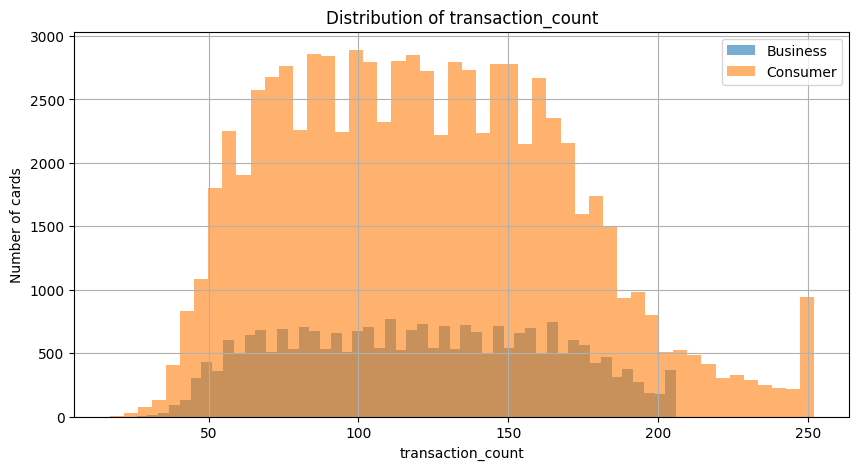

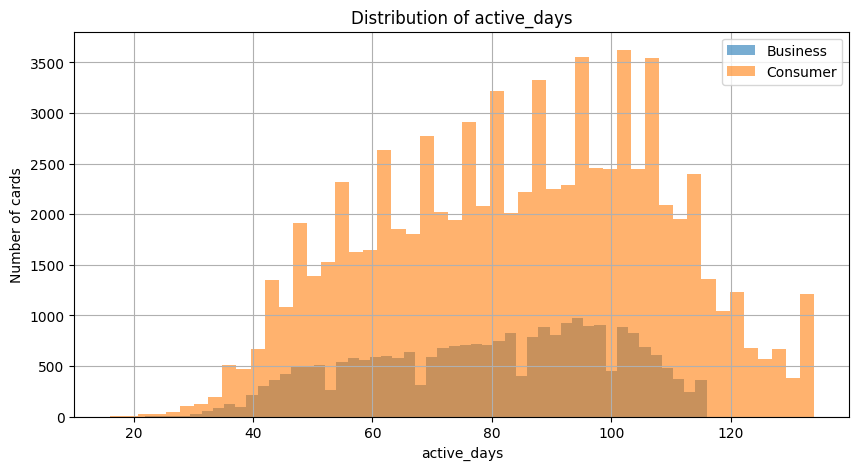

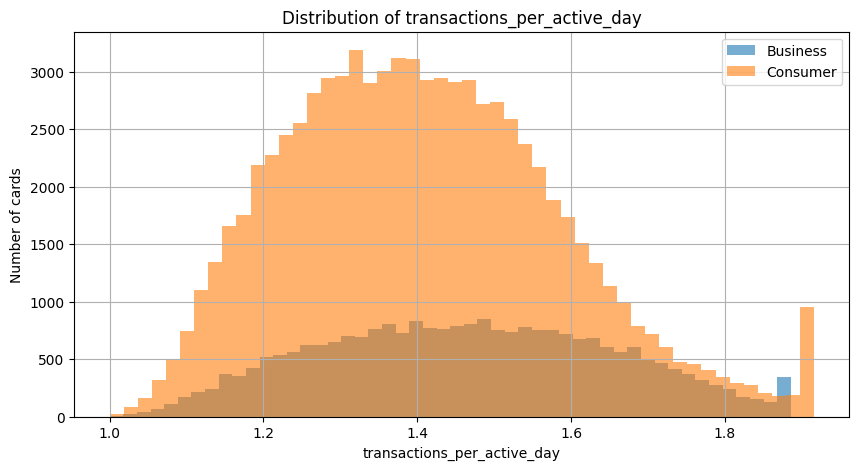

In [33]:
plot_card_feature_distribution(business_activity, consumer_activity, 'transaction_count')
plot_card_feature_distribution(business_activity, consumer_activity, 'active_days')
plot_card_feature_distribution(business_activity, consumer_activity, 'transactions_per_active_day')

#### Card Activity — the Most Surprising Insight

Businesses and consumers make almost the same number of transactions:

* median of 119 transactions for businesses,
* median of 120 for consumers.

They are also active for nearly the same number of days:

* 82 active days for businesses,
* 86 for consumers.

The transaction frequency is nearly identical as well — about 1.4 transactions per day.

This means that a model based only on “how often the card is used” would fail to distinguish businesses from consumers.

The real difference lies in transaction volume:

* business turnover reaches 17.7 million KZT,
* while consumer turnover is only 2.98 million KZT — almost 6 times lower.

The conclusion is straightforward: the distinction is driven not by the number of purchases, but by the amount of money being spent and where it is being spent.

### **Merchant behaviour analysis**

In [34]:
merchant_col = 'merchant_id'

In [35]:
def merchant_features(df, merchant_col, amount_col):
    merchant_counts = (
        df.groupby(['card_number', merchant_col])
        .size()
        .reset_index(name='merchant_txn_count')
    )
    
    top_merchant_share = (
        merchant_counts.groupby('card_number')['merchant_txn_count'].max()
        / merchant_counts.groupby('card_number')['merchant_txn_count'].sum()
    ).reset_index(name='top_merchant_share')
    
    features = df.groupby('card_number').agg(
        unique_merchants=(merchant_col, 'nunique'),
        total_transactions=(merchant_col, 'count')
    ).reset_index()
    
    features = features.merge(top_merchant_share, on='card_number', how='left')
    
    return features

In [36]:
business_merchant = merchant_features(business_df, merchant_col, amount_col)
consumer_merchant = merchant_features(consumer_df, merchant_col, amount_col)

display(business_merchant.head())
display(consumer_merchant.head())

,card_number,unique_merchants,total_transactions,top_merchant_share
0,5100610003025081,9,178,0.432584
1,5100610003044611,18,106,0.349057
2,5100610003860784,8,148,0.466216
3,5100610008756482,27,196,0.433673
4,5100610013466473,19,120,0.375000


,card_number,unique_merchants,total_transactions,top_merchant_share
0,5100610005930965,7,43,0.441860
1,5100610005962109,46,119,0.100840
2,5100610007285137,29,96,0.104167
3,5100610011916156,44,152,0.105263
4,5100610012043588,38,62,0.112903


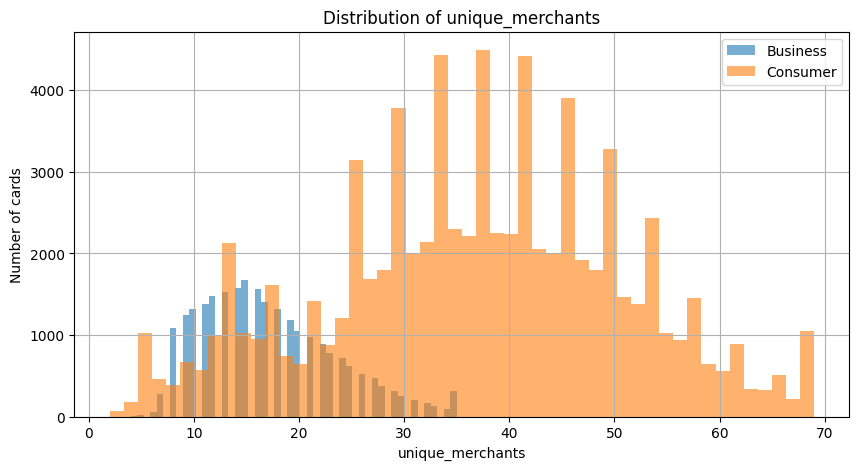

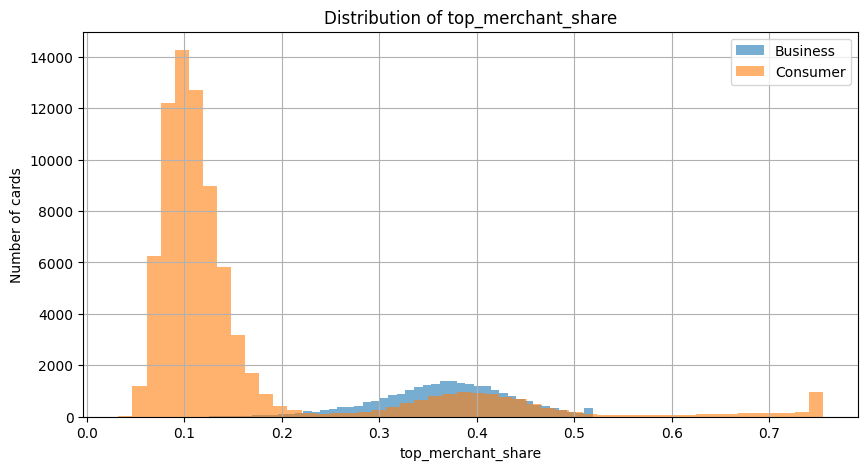

In [37]:
plot_card_feature_distribution(business_merchant, consumer_merchant, 'unique_merchants')
plot_card_feature_distribution(business_merchant, consumer_merchant, 'top_merchant_share')

### Merchant Behavior Patterns

Businesses concentrate their spending within a much smaller set of merchants:

median of 16 unique merchants per business card,
compared to 37 for consumer cards.

In addition, the top merchant accounts for 37% of a business card’s total turnover, while for consumers the top merchant represents only 11%.

This is a classic business behavior pattern: a large share of spending consistently goes to the same supplier, service, or subscription.

Consumer spending, on the other hand, is much more diversified

### **MCC/Category analysis**

In [38]:
mcc_col = 'mcc' 

In [39]:
def top_categories(df, col, name, top_n=20):
    result = (
        df[col]
        .value_counts(normalize=True)
        .head(top_n)
        .reset_index()
    )
    result.columns = [col, 'share']
    
    print(f"Top {top_n} {col} for {name}")
    display(result)
    
    plt.figure(figsize=(10, 5))
    plt.bar(result[col].astype(str), result['share'])
    plt.title(f'{name}: Top {top_n} {col}')
    plt.xticks(rotation=90)
    plt.ylabel('Share')
    plt.show()

Top 20 mcc for Business


,mcc,share
0,7311,0.090582
1,7372,0.079960
2,5968,0.068586
3,4816,0.063314
4,7399,0.036350
5,7011,0.031707
6,4511,0.031568
7,5045,0.031373
8,7392,0.031299
9,4814,0.030581


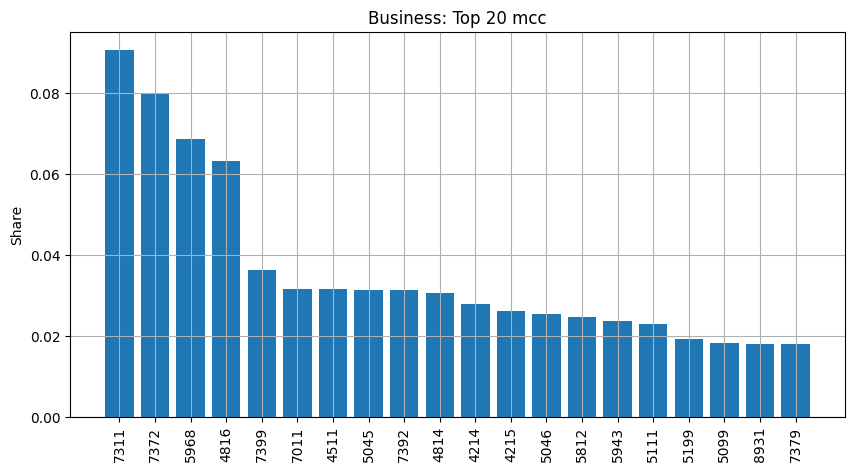

Top 20 mcc for Consumer


,mcc,share
0,4814,0.045917
1,5812,0.045709
2,4121,0.041120
3,5541,0.040182
4,4111,0.029211
5,7311,0.026048
6,5814,0.025803
7,4899,0.025422
8,5411,0.022801
9,5311,0.022532


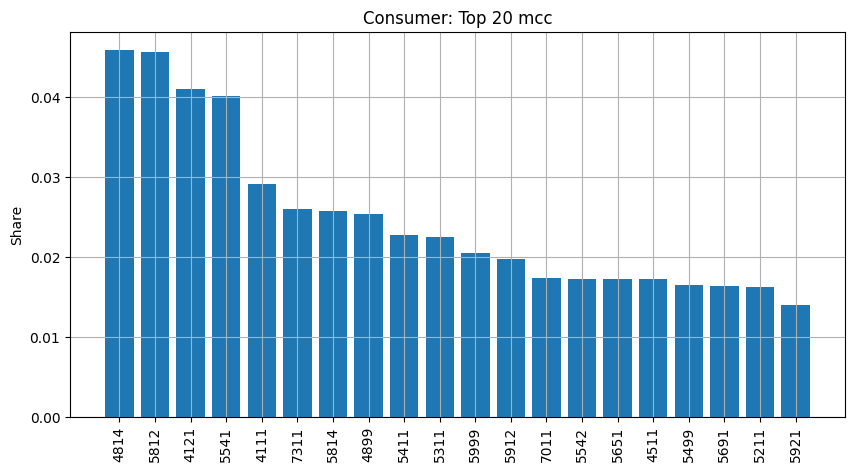

In [40]:
top_categories(business_df, mcc_col, "Business")
top_categories(consumer_df, mcc_col, "Consumer")

In [41]:
def mcc_features(df, mcc_col):
    mcc_counts = (
        df.groupby(['card_number', mcc_col])
        .size()
        .reset_index(name='mcc_txn_count')
    )
    
    top_mcc_share = (
        mcc_counts.groupby('card_number')['mcc_txn_count'].max()
        / mcc_counts.groupby('card_number')['mcc_txn_count'].sum()
    ).reset_index(name='top_mcc_share')
    
    features = df.groupby('card_number').agg(
        unique_mcc=(mcc_col, 'nunique'),
        total_transactions=(mcc_col, 'count')
    ).reset_index()
    
    features = features.merge(top_mcc_share, on='card_number', how='left')
    
    return features

In [42]:
business_mcc = mcc_features(business_df, mcc_col)
consumer_mcc = mcc_features(consumer_df, mcc_col)

display(business_mcc.head())
display(consumer_mcc.head())

,card_number,unique_mcc,total_transactions,top_mcc_share
0,5100610003025081,9,178,0.432584
1,5100610003044611,18,106,0.349057
2,5100610003860784,8,148,0.466216
3,5100610008756482,18,196,0.433673
4,5100610013466473,19,120,0.375000


,card_number,unique_mcc,total_transactions,top_mcc_share
0,5100610005930965,7,43,0.441860
1,5100610005962109,43,119,0.109244
2,5100610007285137,26,96,0.114583
3,5100610011916156,36,152,0.105263
4,5100610012043588,31,62,0.112903


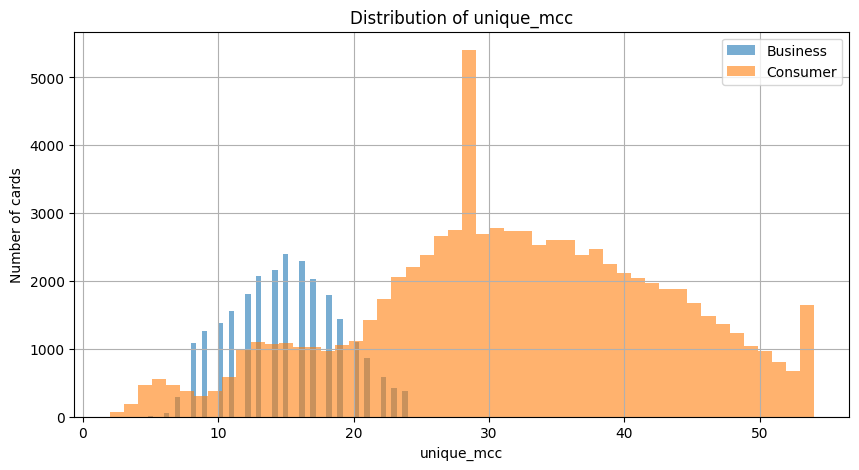

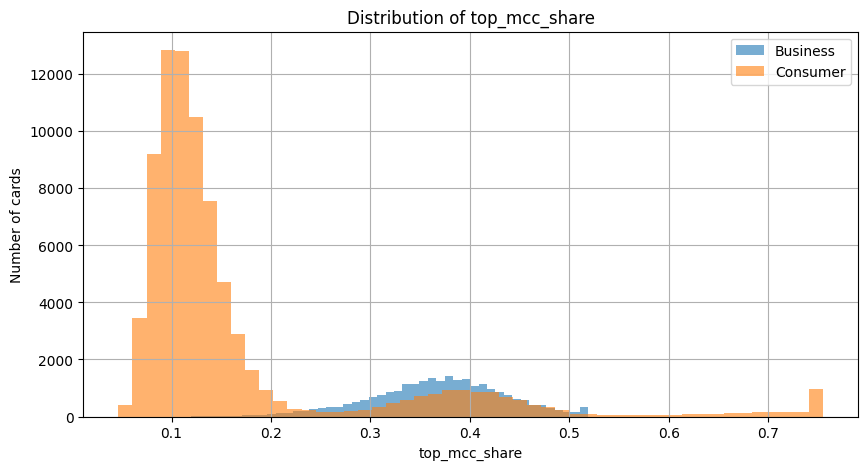

In [43]:
plot_card_feature_distribution(business_mcc, consumer_mcc, 'unique_mcc')
plot_card_feature_distribution(business_mcc, consumer_mcc, 'top_mcc_share')

### MCC 

Top 5 categories for businesses: advertising (Google/Meta Ads), cloud services (AWS), subscriptions, digital services, B2B services. In other words, these are “tools for work.” Top 5 for consumers: telecom, restaurants, taxis, gas stations, public transport — everyday life spending.

This is probably the most straightforward signal in the dataset: a card that pays for Google Ads is a business card, even if it is registered to an individual.

### **Geography analysis**

In [44]:
country_col = 'country' 

In [45]:
def geography_features(df, country_col):
    features = df.groupby('card_number').agg(
        unique_countries=(country_col, 'nunique'),
        total_transactions=(country_col, 'count')
    ).reset_index()
    
    return features

In [46]:
business_geo = geography_features(business_df, country_col)
consumer_geo = geography_features(consumer_df, country_col)

display(business_geo.head())
display(consumer_geo.head())

,card_number,unique_countries,total_transactions
0,5100610003025081,9,178
1,5100610003044611,5,106
2,5100610003860784,3,148
3,5100610008756482,10,196
4,5100610013466473,5,120


,card_number,unique_countries,total_transactions
0,5100610005930965,4,43
1,5100610005962109,9,119
2,5100610007285137,8,96
3,5100610011916156,13,152
4,5100610012043588,8,62


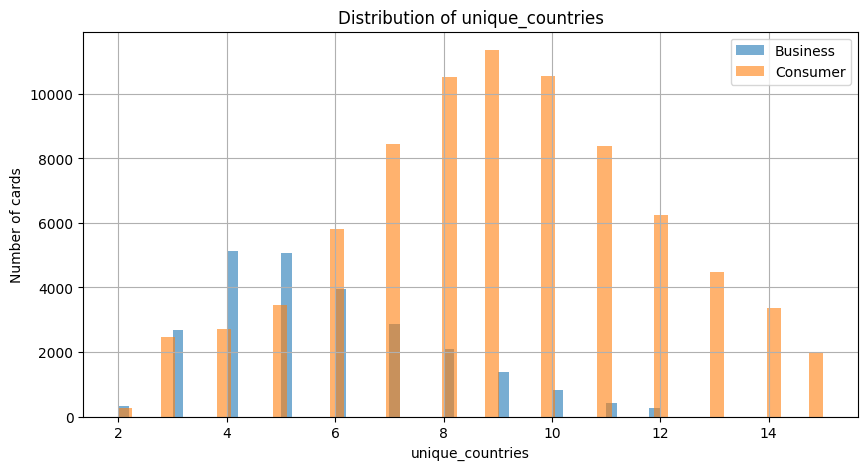

In [47]:
plot_card_feature_distribution(business_geo, consumer_geo, 'unique_countries')

Top 20 country for Business


,country,share
0,Kazakhstan,0.706862
1,US,0.116140
2,Ireland,0.049228
3,China,0.019045
4,UAE,0.017777
5,Germany,0.017634
6,Australia,0.016214
7,Russia,0.015344
8,Singapore,0.011238
9,Canada,0.007702


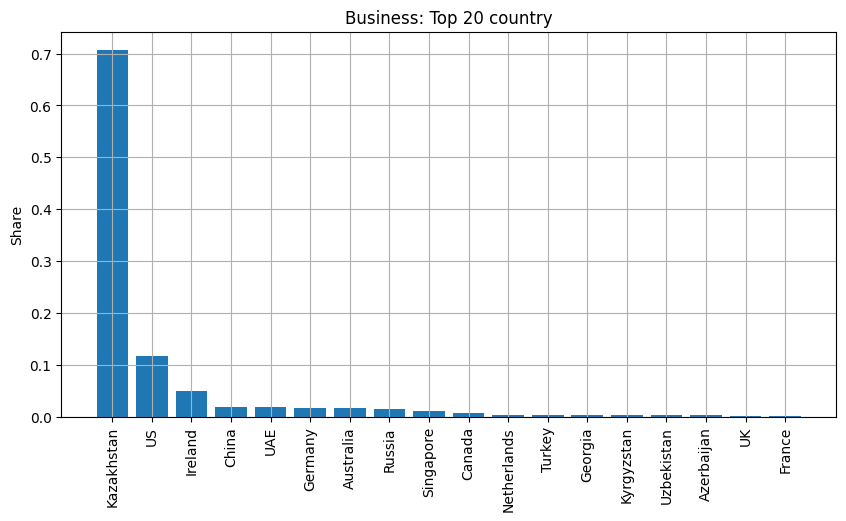

Top 20 country for Consumer


,country,share
0,Kazakhstan,0.738435
1,China,0.057995
2,US,0.053087
3,UAE,0.046848
4,Russia,0.014457
5,Ireland,0.010129
6,Turkey,0.009939
7,Netherlands,0.009213
8,Germany,0.009094
9,Uzbekistan,0.008328


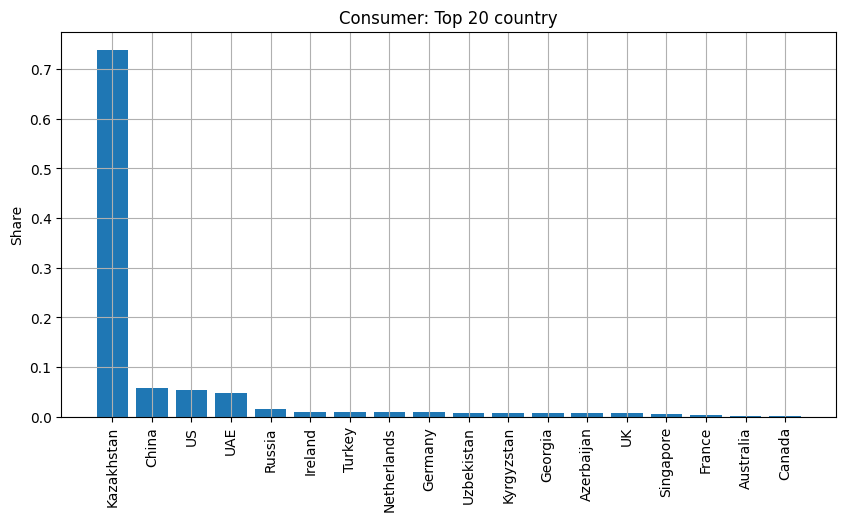

In [48]:
top_categories(business_df, country_col, "Business")
top_categories(consumer_df, country_col, "Consumer")

### Geography

Here the popular myth that “business spends more abroad” breaks down. In reality, both segments have ~71–74% of spending inside Kazakhstan.

The difference is where the foreign spend goes.

For businesses, a large share goes to the United States (11.6%) and Ireland (4.9%) — which are the home countries of services like Google Ads (Ireland), Meta Ads (Ireland), and AWS (USA). This is not tourism, but payments for foreign business services.

For consumers, foreign payments are spread across China, the UAE, Turkey, and the US — typical shopping and travel behavior.

Another interesting point: consumers interact with ~9 countries on average, while businesses interact with ~5. It seems counterintuitive, but it makes sense — consumers make small purchases across many international retailers.

### **Time behavior analysis**

In [49]:
def add_time_features(df, timestamp_col='transaction_timestamp'):
    """
    Create time-based features at the transaction level.
    IMPORTANT: use 'transaction_timestamp' (full datetime with hour),
    NOT 'transaction_date' (which is a pure date with hour=0 for every row).
    """
    df = df.copy()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])

    df['hour']              = df[timestamp_col].dt.hour
    df['day_of_week']       = df[timestamp_col].dt.dayofweek
    df['is_weekend']        = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_business_hours'] = df['hour'].between(9, 18).astype(int)
    df['is_night']          = df['hour'].between(0, 6).astype(int)

    return df

In [50]:
business_df_time = add_time_features(business_df, 'transaction_timestamp')
consumer_df_time = add_time_features(consumer_df, 'transaction_timestamp')

In [51]:
def temporal_features(df):
    features = df.groupby('card_number').agg(
        weekend_share=('is_weekend', 'mean'),
        business_hours_share=('is_business_hours', 'mean'),
        night_share=('is_night', 'mean'),
        avg_transaction_hour=('hour', 'mean'),
        std_transaction_hour=('hour', 'std')
    ).reset_index()
    
    return features

In [52]:
business_time = temporal_features(business_df_time)
consumer_time = temporal_features(consumer_df_time)

display(business_time.head())
display(consumer_time.head())

,card_number,weekend_share,business_hours_share,night_share,avg_transaction_hour,std_transaction_hour
0,5100610003025081,0.101124,0.758427,0.095506,12.617978,4.758592
1,5100610003044611,0.122642,0.698113,0.169811,11.933962,5.620149
2,5100610003860784,0.114865,0.844595,0.047297,12.966216,3.983667
3,5100610008756482,0.142857,0.750000,0.066327,12.693878,4.651789
4,5100610013466473,0.083333,0.758333,0.175000,11.475000,5.146529


,card_number,weekend_share,business_hours_share,night_share,avg_transaction_hour,std_transaction_hour
0,5100610005930965,0.232558,0.465116,0.418605,9.488372,6.663233
1,5100610005962109,0.302521,0.588235,0.092437,14.016807,5.523422
2,5100610007285137,0.343750,0.583333,0.062500,15.125000,5.159049
3,5100610011916156,0.355263,0.677632,0.032895,14.644737,4.580997
4,5100610012043588,0.274194,0.741935,0.000000,15.612903,3.901890


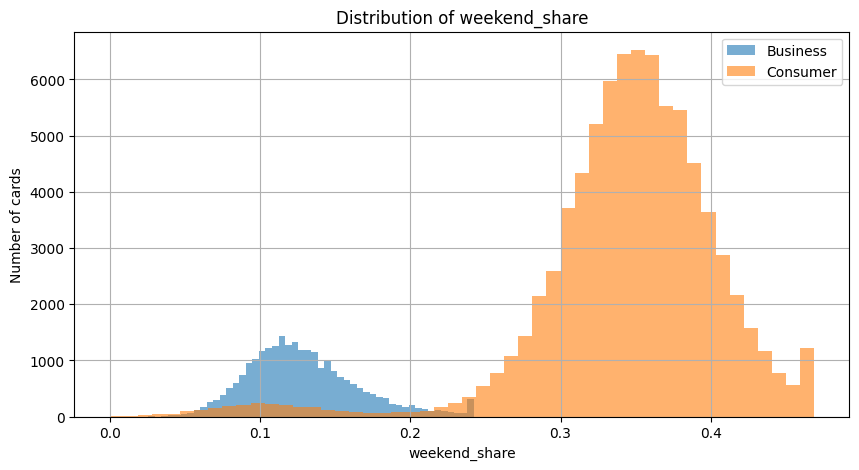

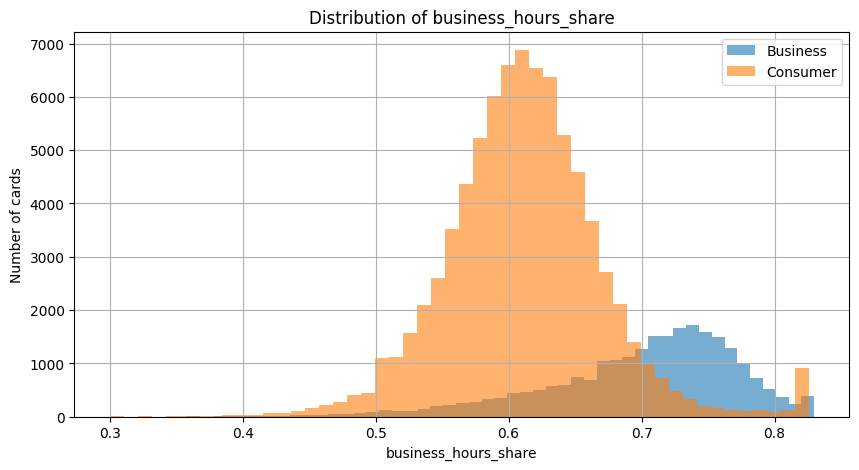

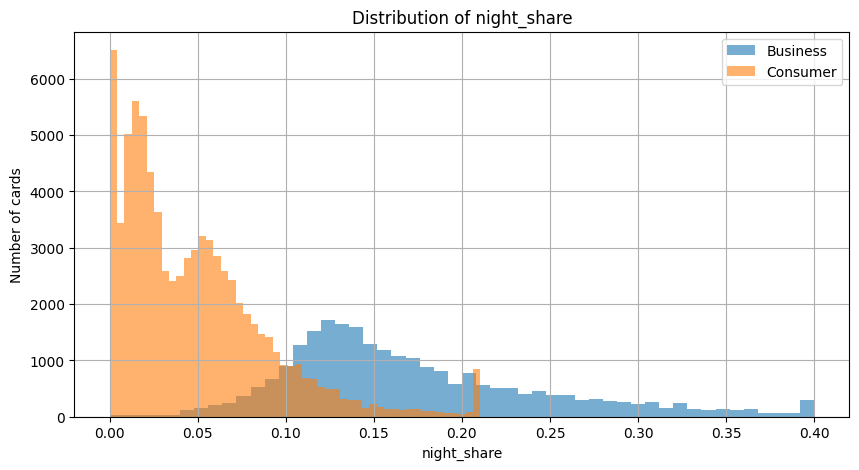

In [53]:
plot_card_feature_distribution(business_time, consumer_time, 'weekend_share')
plot_card_feature_distribution(business_time, consumer_time, 'business_hours_share')
plot_card_feature_distribution(business_time, consumer_time, 'night_share')

### Temporal patterns

Businesses show much lower weekend activity (12.4% vs 35.0%), reflecting a weekday-oriented operational cycle.

During working hours (09:00–18:00), both segments are concentrated, but the effect is stronger for businesses (71% vs 61%), making this a weak-to-moderate signal.

The strongest separation appears at night (00:00–06:00): businesses have 15% of transactions versus 4% for consumers. This is driven by automated billing processes (ads, cloud, subscriptions), which run independently of human activity, while consumer nighttime spending remains minimal.

### **Regularity analysis**

In [54]:
def regularity_features(df, amount_col, date_col):
    temp = df.copy()
    temp[date_col] = pd.to_datetime(temp[date_col])
    
    amount_counts = (
        temp.groupby(['card_number', amount_col])
        .size()
        .reset_index(name='amount_count')
    )
    
    repeated_amount_share = (
        amount_counts[amount_counts['amount_count'] > 1]
        .groupby('card_number')['amount_count']
        .sum()
        / temp.groupby('card_number').size()
    ).reset_index(name='repeated_amount_share')
    
    temp = temp.sort_values(['card_number', date_col])
    temp['days_between_txn'] = temp.groupby('card_number')[date_col].diff().dt.days
    
    interval_features = temp.groupby('card_number').agg(
        avg_days_between_txn=('days_between_txn', 'mean'),
        std_days_between_txn=('days_between_txn', 'std')
    ).reset_index()
    
    features = interval_features.merge(
        repeated_amount_share,
        on='card_number',
        how='left'
    )
    
    features['repeated_amount_share'] = features['repeated_amount_share'].fillna(0)
    
    return features

In [55]:
business_regular = regularity_features(business_df, amount_col, date_col)
consumer_regular = regularity_features(consumer_df, amount_col, date_col)

display(business_regular.head())
display(consumer_regular.head())

,card_number,avg_days_between_txn,std_days_between_txn,repeated_amount_share
0,5100610003025081,1.022599,1.242957,0.067416
1,5100610003044611,1.723810,1.689875,0.169811
2,5100610003860784,1.231293,1.485399,0.040541
3,5100610008756482,0.923077,1.213851,0.061224
4,5100610013466473,1.504202,1.635796,0.150000


,card_number,avg_days_between_txn,std_days_between_txn,repeated_amount_share
0,5100610005930965,4.285714,3.133499,0.418605
1,5100610005962109,1.525424,1.698224,0.050420
2,5100610007285137,1.842105,1.752298,0.062500
3,5100610011916156,1.185430,1.353534,0.000000
4,5100610012043588,2.950820,2.912194,0.000000


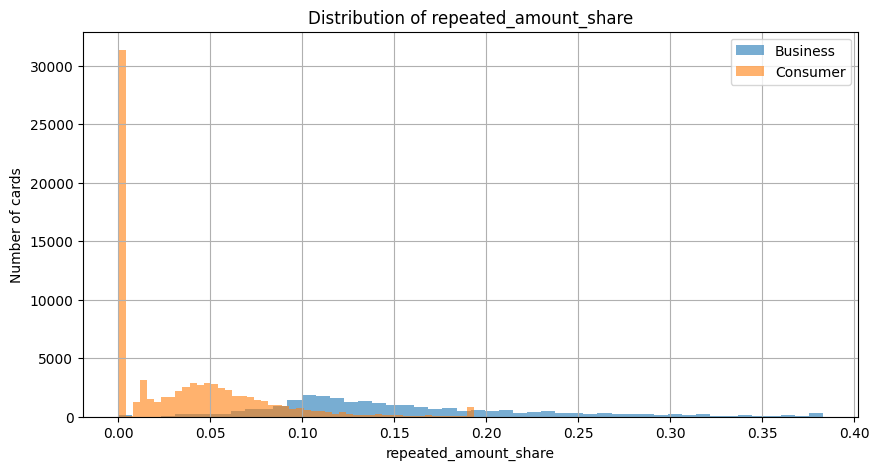

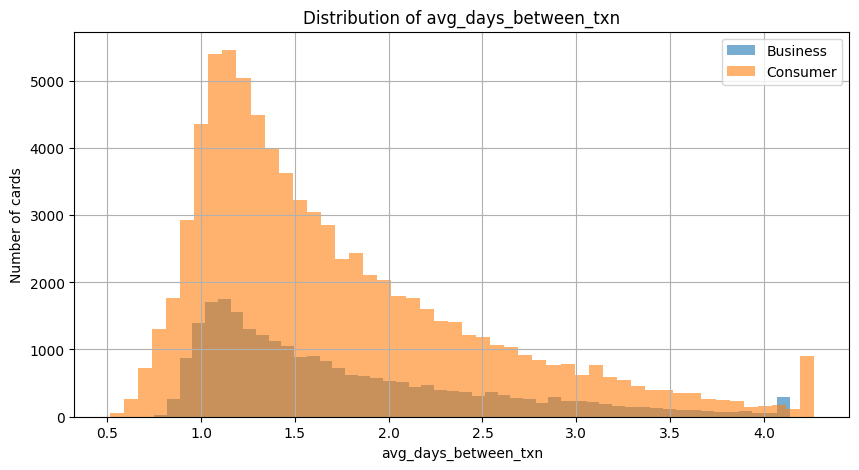

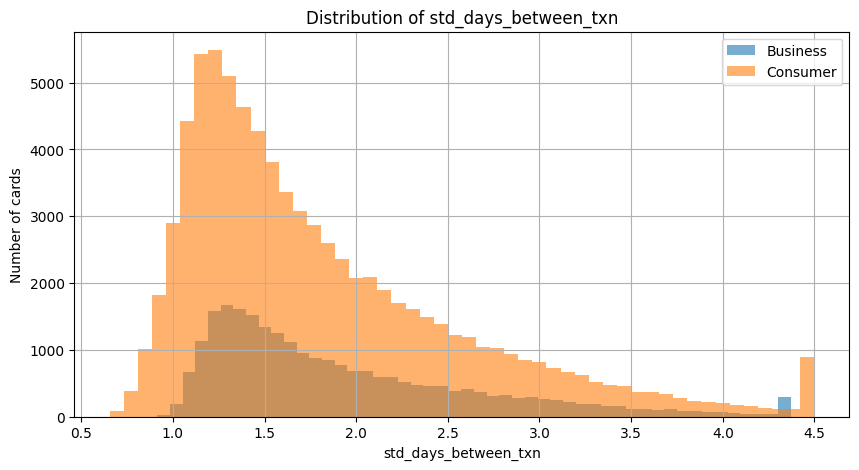

In [56]:
plot_card_feature_distribution(business_regular, consumer_regular, 'repeated_amount_share')
plot_card_feature_distribution(business_regular, consumer_regular, 'avg_days_between_txn')
plot_card_feature_distribution(business_regular, consumer_regular, 'std_days_between_txn')

### Payment regularity

One of the strongest signals in the dataset is the share of repeated identical transactions. For businesses, 13.5% of transactions are recurring payments with the same amount (subscriptions, recurring vendor payments, advertising billing). For consumers, this figure is only 2.6%, which is approximately 5 times lower.

In contrast, the average interval between transactions is nearly identical for both groups (~1.5 days). This feature does not provide meaningful separation power and can therefore be excluded as a predictive signal.

### Final EDA dataset 

In [57]:
def build_card_level_dataset(df, amount_col, date_col, merchant_col, mcc_col, country_col):

    df = df.copy()

    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    # TIME FEATURES
    df_time = add_time_features(df, date_col)

    # FEATURE BLOCKS
    amount = card_amount_features(df, amount_col)

    activity = activity_features(df, date_col)

    merchant = merchant_features(df, merchant_col, amount_col)

    mcc = mcc_features(df, mcc_col)

    geo = geography_features(df, country_col)

    time = temporal_features(df_time)

    regular = regularity_features(df, amount_col, date_col)

    # START MERGING
    card_features = amount.copy()

    for feature_df in [activity, merchant, mcc, geo, time, regular]:

        duplicate_cols = [
            col for col in feature_df.columns
            if col != 'card_number' and col in card_features.columns
        ]

        feature_df = feature_df.drop(columns=duplicate_cols, errors='ignore')

        card_features = card_features.merge(
            feature_df,
            on='card_number',
            how='left'
        )

    return card_features

In [58]:
date_col = 'transaction_timestamp'

business_df[date_col] = pd.to_datetime(business_df[date_col], errors='coerce')
consumer_df[date_col] = pd.to_datetime(consumer_df[date_col], errors='coerce')

print(business_df[date_col].dtype)
print(consumer_df[date_col].dtype)

print("Business missing timestamps:", business_df[date_col].isna().sum())
print("Consumer missing timestamps:", consumer_df[date_col].isna().sum())

datetime64[ms]
datetime64[ms]
Business missing timestamps: 0
Consumer missing timestamps: 0


In [59]:
business_card_features = build_card_level_dataset(
    business_df,
    amount_col=amount_col,
    date_col='transaction_timestamp',
    merchant_col=merchant_col,
    mcc_col=mcc_col,
    country_col=country_col
)

consumer_card_features = build_card_level_dataset(
    consumer_df,
    amount_col=amount_col,
    date_col='transaction_timestamp',
    merchant_col=merchant_col,
    mcc_col=mcc_col,
    country_col=country_col
)

In [60]:
print("Business card-level shape:", business_card_features.shape)
print("Consumer card-level shape:", consumer_card_features.shape)

display(business_card_features.head())
display(consumer_card_features.head())

Business card-level shape: (25000, 28)
Consumer card-level shape: (80000, 28)


,card_number,total_amount,mean_amount,median_amount,std_amount,max_amount,min_amount,transaction_count,first_transaction,last_transaction,...,top_mcc_share,unique_countries,weekend_share,business_hours_share,night_share,avg_transaction_hour,std_transaction_hour,avg_days_between_txn,std_days_between_txn,repeated_amount_share
0,5100610003025081,9651486,54221.831461,14499.0,92378.778008,745914,659,178,2025-10-01 10:10:48,2026-03-31 17:31:18,...,0.432584,9,0.101124,0.758427,0.095506,12.617978,4.758592,0.604520,1.128949,0.067416
1,5100610003044611,14353608,135411.396226,67810.0,198947.026012,1483178,604,106,2025-10-01 18:54:43,2026-03-31 10:40:21,...,0.349057,5,0.122642,0.698113,0.169811,11.933962,5.620149,1.276190,1.637865,0.169811
2,5100610003860784,13102356,88529.432432,56445.0,101798.906783,652796,262,148,2025-10-01 13:33:58,2026-03-31 16:49:50,...,0.466216,3,0.114865,0.844595,0.047297,12.966216,3.983667,0.816327,1.303422,0.040541
3,5100610008756482,27341119,139495.505102,98362.5,163409.474324,1286163,1208,196,2025-10-01 09:18:04,2026-03-30 15:10:28,...,0.433673,10,0.142857,0.750000,0.066327,12.693878,4.651789,0.528205,1.026943,0.061224
4,5100610013466473,16439793,136998.275000,46989.0,185183.080133,982511,326,120,2025-10-03 02:59:00,2026-03-31 16:44:11,...,0.375000,5,0.083333,0.758333,0.175000,11.475000,5.146529,1.126050,1.537964,0.150000


,card_number,total_amount,mean_amount,median_amount,std_amount,max_amount,min_amount,transaction_count,first_transaction,last_transaction,...,top_mcc_share,unique_countries,weekend_share,business_hours_share,night_share,avg_transaction_hour,std_transaction_hour,avg_days_between_txn,std_days_between_txn,repeated_amount_share
0,5100610005930965,14215001,330581.418605,168999.0,457017.109755,2137325,4410,43,2025-10-02 00:14:00,2026-03-31 22:31:44,...,0.441860,4,0.232558,0.465116,0.418605,9.488372,6.663233,3.761905,3.121988,0.418605
1,5100610005962109,1303168,10950.991597,5886.0,23120.959998,223504,347,119,2025-10-02 13:49:11,2026-03-31 21:44:52,...,0.109244,9,0.302521,0.588235,0.092437,14.016807,5.523422,1.110169,1.534692,0.050420
2,5100610007285137,1202801,12529.177083,4803.0,23919.649464,190489,396,96,2025-10-04 11:08:04,2026-03-28 11:52:54,...,0.114583,8,0.343750,0.583333,0.062500,15.125000,5.159049,1.421053,1.753895,0.062500
3,5100610011916156,2916033,19184.427632,9465.5,37685.428473,404648,688,152,2025-10-02 17:28:22,2026-03-30 11:49:39,...,0.105263,13,0.355263,0.677632,0.032895,14.644737,4.580997,0.721854,1.217423,0.000000
4,5100610012043588,1796507,28975.919355,11653.0,56269.532103,342115,197,62,2025-10-01 18:06:27,2026-03-30 10:03:38,...,0.112903,8,0.274194,0.741935,0.000000,15.612903,3.901890,2.508197,2.711844,0.000000


In [61]:
business_card_features.describe()

,total_amount,mean_amount,median_amount,std_amount,max_amount,min_amount,transaction_count,first_transaction,last_transaction,active_days,...,top_mcc_share,unique_countries,weekend_share,business_hours_share,night_share,avg_transaction_hour,std_transaction_hour,avg_days_between_txn,std_days_between_txn,repeated_amount_share
count,2.500000e+04,25000.000000,25000.000000,2.500000e+04,2.500000e+04,25000.000000,25000.000000,25000,25000,25000.000000,...,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,1.876916e+07,167642.447808,92225.245400,2.301465e+05,1.494760e+06,1810.038080,119.903720,2025-10-02 22:39:08.284000,2026-03-30 20:16:39.285000,79.608760,...,0.368192,5.73972,0.129070,0.700615,0.171970,11.686331,5.219337,1.334263,1.841824,0.155679
min,2.615035e+06,26838.925466,2116.000000,4.502473e+04,2.076620e+05,67.000000,26.000000,2025-10-01 00:00:00,2026-03-06 05:25:00,22.000000,...,0.094118,2.00000,0.025641,0.348837,0.000000,7.324324,3.131382,0.388393,0.764373,0.000000
25%,1.363701e+07,125838.931548,59458.625000,1.635633e+05,8.624258e+05,670.000000,84.000000,2025-10-01 11:57:20.250000,2026-03-30 16:27:40.750000,63.000000,...,0.326087,4.00000,0.103093,0.661765,0.120482,11.235294,4.862302,0.761290,1.246250,0.104632
50%,1.771489e+07,155609.899373,84558.500000,2.044494e+05,1.204462e+06,1080.000000,119.000000,2025-10-02 04:07:30,2026-03-31 12:44:04,82.000000,...,0.371173,5.00000,0.124138,0.714286,0.153001,11.868950,5.158762,1.086207,1.603713,0.135338
75%,2.288589e+07,193926.926776,115733.375000,2.633677e+05,1.761576e+06,1876.250000,155.000000,2025-10-03 10:29:00.250000,2026-03-31 16:41:24.250000,97.000000,...,0.413534,7.00000,0.149254,0.751351,0.208989,12.291170,5.551319,1.707703,2.240199,0.193548
max,6.435703e+07,776261.333333,612595.500000,3.291898e+06,4.079930e+07,64365.000000,242.000000,2025-11-06 15:04:06,2026-03-31 23:59:53,128.000000,...,0.725490,15.00000,0.392405,0.943396,0.545455,14.400000,7.314202,6.440000,8.664169,0.545455
std,6.897553e+06,64423.261719,50852.489384,1.110944e+05,1.125650e+06,2718.911361,43.044349,NaN,NaN,20.566918,...,0.068243,2.10504,0.037904,0.072516,0.075086,0.891380,0.521776,0.752542,0.788384,0.075303


In [62]:
consumer_card_features.describe()

,total_amount,mean_amount,median_amount,std_amount,max_amount,min_amount,transaction_count,first_transaction,last_transaction,active_days,...,top_mcc_share,unique_countries,weekend_share,business_hours_share,night_share,avg_transaction_hour,std_transaction_hour,avg_days_between_txn,std_days_between_txn,repeated_amount_share
count,8.000000e+04,8.000000e+04,8.000000e+04,8.000000e+04,8.000000e+04,80000.000000,80000.000000,80000,80000,80000.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,6.642512e+06,5.477014e+04,2.311945e+04,9.997246e+04,7.364325e+05,1095.116788,122.906087,2025-10-03 02:57:01.412000,2026-03-30 08:19:35.593000,84.660200,...,0.167431,9.047788,0.345226,0.612375,0.048926,14.928943,4.876568,1.300043,1.744529,0.035852
min,3.452870e+05,5.446994e+03,2.134000e+03,5.798632e+03,2.435200e+04,15.000000,17.000000,2025-10-01 00:00:00,2026-02-24 13:57:49,16.000000,...,0.046512,2.000000,0.000000,0.300000,0.000000,7.230769,2.750028,0.184211,0.462987,0.000000
25%,1.966989e+06,1.714747e+04,5.919000e+03,3.186985e+04,2.096278e+05,371.000000,85.000000,2025-10-01 16:28:29.250000,2026-03-29 18:33:27.750000,66.000000,...,0.096970,7.000000,0.318841,0.576923,0.016393,14.594920,4.451217,0.733766,1.139990,0.000000
50%,2.976294e+06,2.677495e+04,9.673500e+03,5.290767e+04,3.731065e+05,576.000000,120.000000,2025-10-02 12:34:13.500000,2026-03-30 20:36:31,86.000000,...,0.118812,9.000000,0.350230,0.611111,0.039773,15.041667,4.822696,1.065041,1.506010,0.026490
75%,6.259916e+06,6.356528e+04,2.638900e+04,1.154282e+05,8.548310e+05,1256.000000,156.000000,2025-10-03 18:55:07.750000,2026-03-31 16:56:03.500000,103.000000,...,0.154762,11.000000,0.381503,0.644444,0.069231,15.429825,5.241170,1.666667,2.144225,0.057554
max,1.701590e+08,2.215910e+06,1.520916e+06,2.547872e+06,3.197103e+07,285067.000000,354.000000,2025-11-11 18:24:30,2026-03-31 23:59:49,157.000000,...,0.975610,17.000000,0.645161,1.000000,0.512821,17.833333,7.688135,9.187500,10.458710,0.486486
std,8.606655e+06,7.123950e+04,3.785588e+04,1.205720e+05,9.500055e+05,1899.347055,47.978862,NaN,NaN,23.755408,...,0.136513,2.846885,0.062719,0.060343,0.044610,0.817057,0.568752,0.779333,0.833931,0.043360


### **Business VS. Comsumers on the card level**

In [63]:
comparison_features = [
    'transaction_count',
    'total_amount',
    'mean_amount',
    'active_days',
    'transactions_per_active_day',
    'unique_merchants',
    'top_merchant_share',
    'unique_mcc',
    'top_mcc_share',
    'unique_countries',
    'weekend_share',
    'business_hours_share',
    'night_share',
    'repeated_amount_share'
]

In [64]:
business_card_features = business_card_features.rename(columns={
    'transaction_count_x': 'transaction_count'
})

consumer_card_features = consumer_card_features.rename(columns={
    'transaction_count_x': 'transaction_count'
})

In [65]:
business_card_features = business_card_features.drop(
    columns=['transaction_count_y', 'total_transactions_x', 'total_transactions_y', 'total_transactions'],
    errors='ignore'
)

consumer_card_features = consumer_card_features.drop(
    columns=['transaction_count_y', 'total_transactions_x', 'total_transactions_y', 'total_transactions'],
    errors='ignore'
)

In [66]:
summary_comparison = pd.DataFrame({
    'feature': comparison_features,
    'business_mean': [business_card_features[col].mean() for col in comparison_features],
    'consumer_mean': [consumer_card_features[col].mean() for col in comparison_features],
    'business_median': [business_card_features[col].median() for col in comparison_features],
    'consumer_median': [consumer_card_features[col].median() for col in comparison_features],
})

summary_comparison['mean_difference'] = summary_comparison['business_mean'] - summary_comparison['consumer_mean']

summary_comparison['business_to_consumer_ratio'] = (
    summary_comparison['business_mean'] / summary_comparison['consumer_mean'].replace(0, np.nan)
)

display(summary_comparison)

,feature,business_mean,consumer_mean,business_median,consumer_median,mean_difference,business_to_consumer_ratio
0,transaction_count,1.199037e+02,1.229061e+02,1.190000e+02,1.200000e+02,-3.002367e+00,0.975572
1,total_amount,1.876916e+07,6.642512e+06,1.771489e+07,2.976294e+06,1.212665e+07,2.825612
2,mean_amount,1.676424e+05,5.477014e+04,1.556099e+05,2.677495e+04,1.128723e+05,3.060837
3,active_days,7.960876e+01,8.466020e+01,8.200000e+01,8.600000e+01,-5.051440e+00,0.940333
4,transactions_per_active_day,1.466502e+00,1.409611e+00,1.463768e+00,1.396040e+00,5.689101e-02,1.040359
5,unique_merchants,1.708732e+01,3.675050e+01,1.600000e+01,3.700000e+01,-1.966318e+01,0.464955
6,top_merchant_share,3.677684e-01,1.607420e-01,3.707865e-01,1.111111e-01,2.070264e-01,2.287942
7,unique_mcc,1.484876e+01,3.168280e+01,1.500000e+01,3.200000e+01,-1.683404e+01,0.468669
8,top_mcc_share,3.681918e-01,1.674307e-01,3.711731e-01,1.188119e-01,2.007611e-01,2.199070
9,unique_countries,5.739720e+00,9.047788e+00,5.000000e+00,9.000000e+00,-3.308067e+00,0.634378


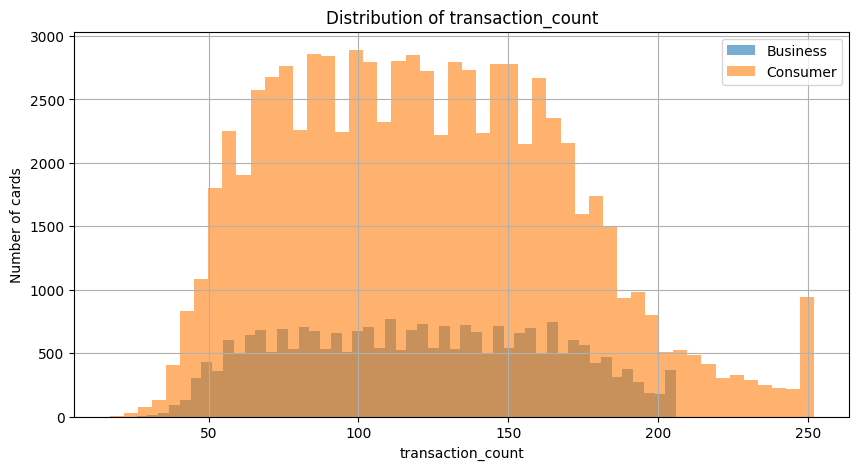

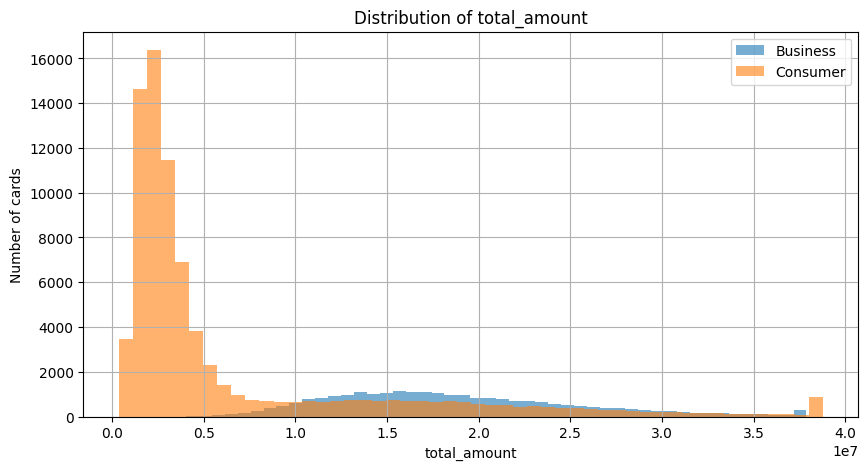

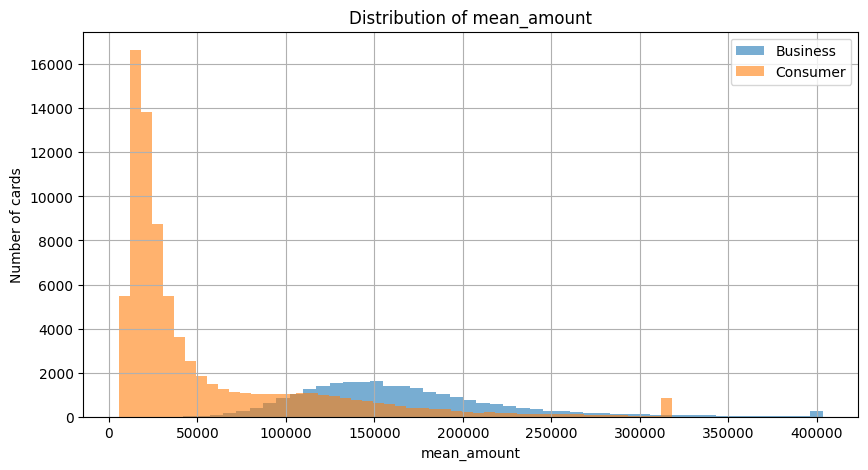

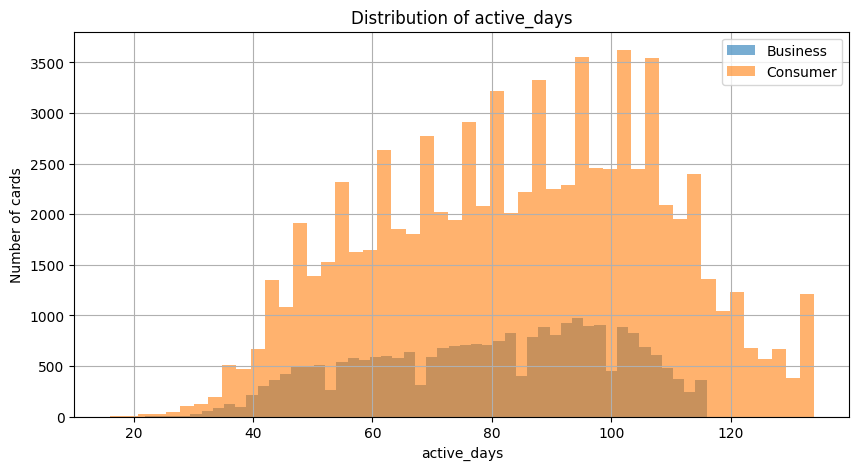

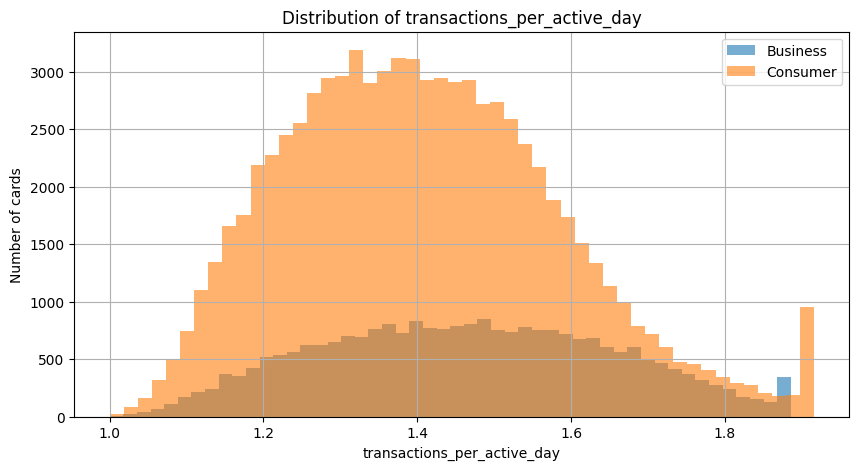

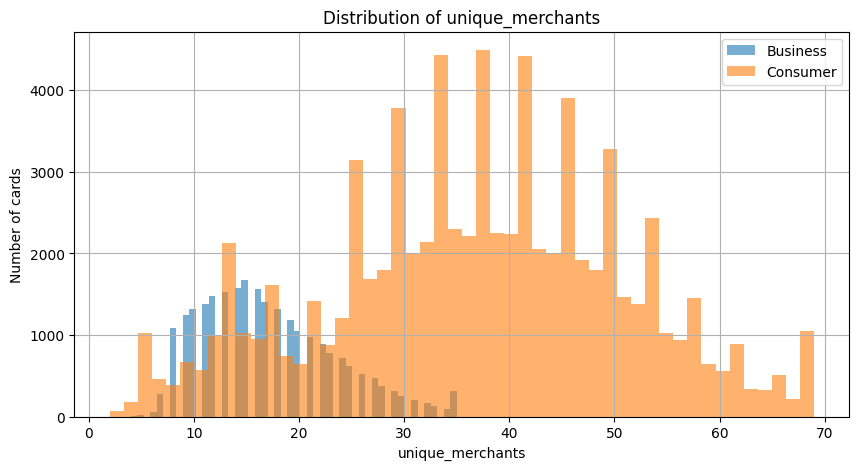

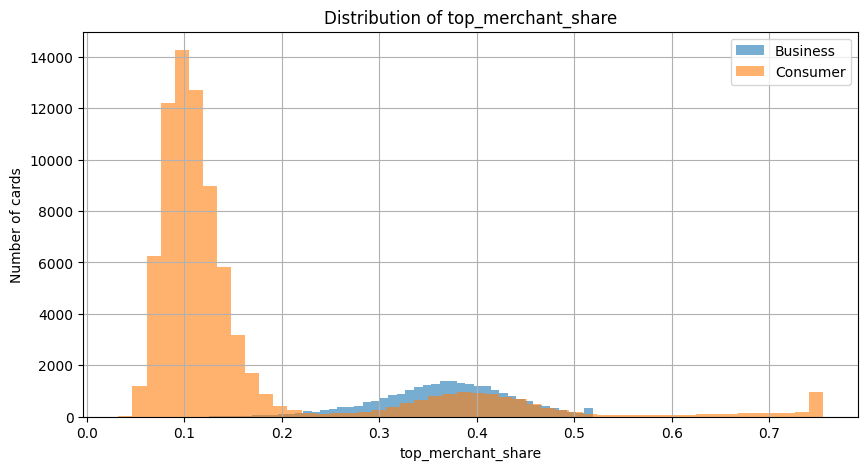

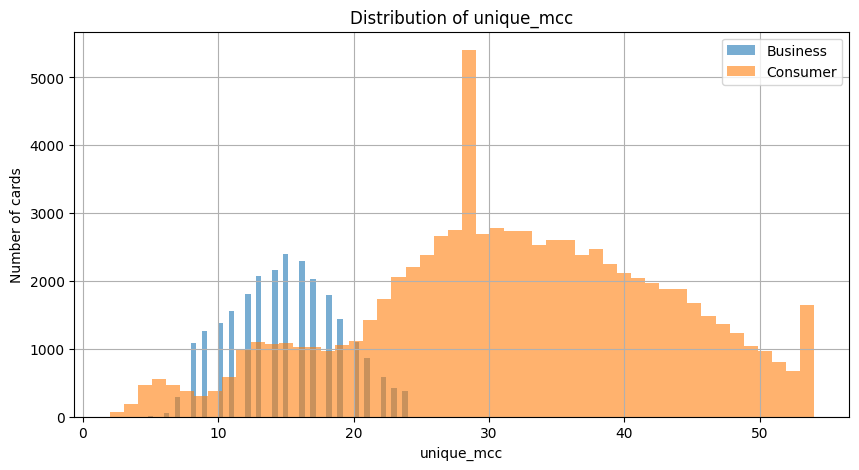

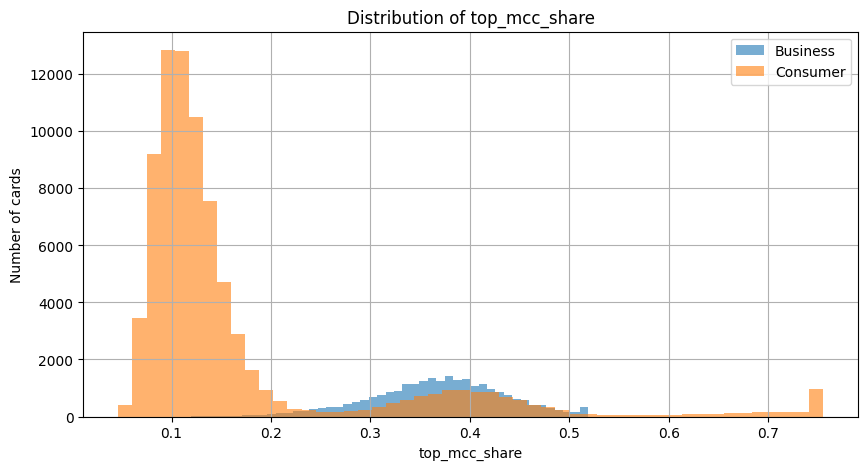

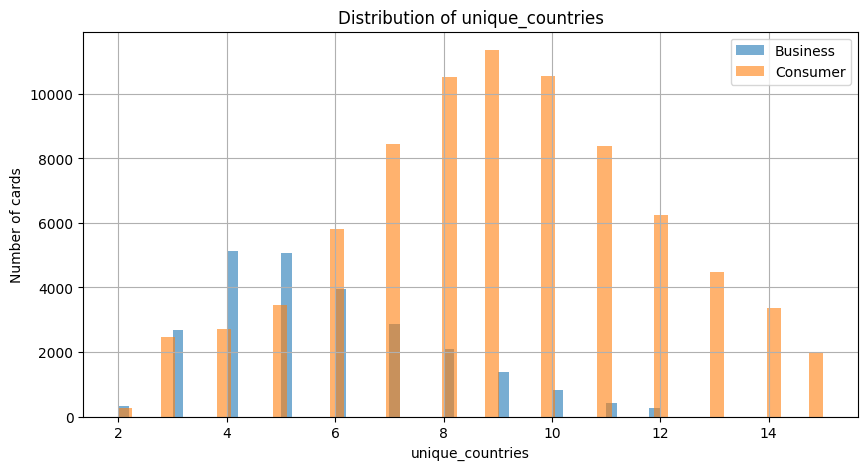

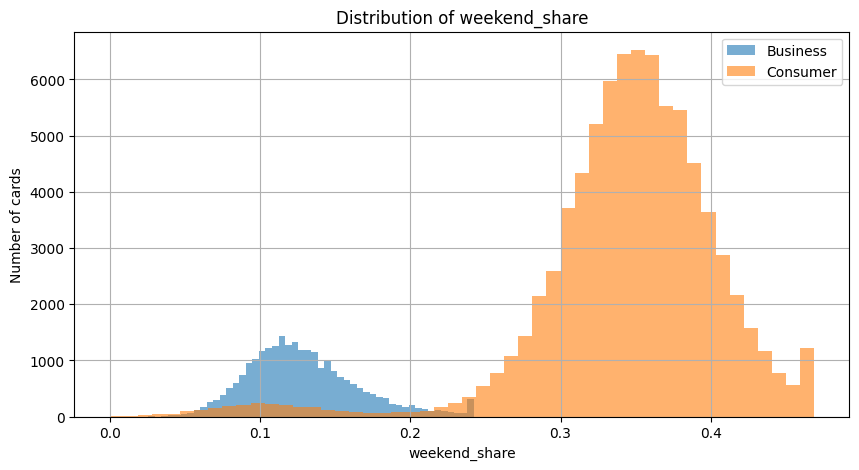

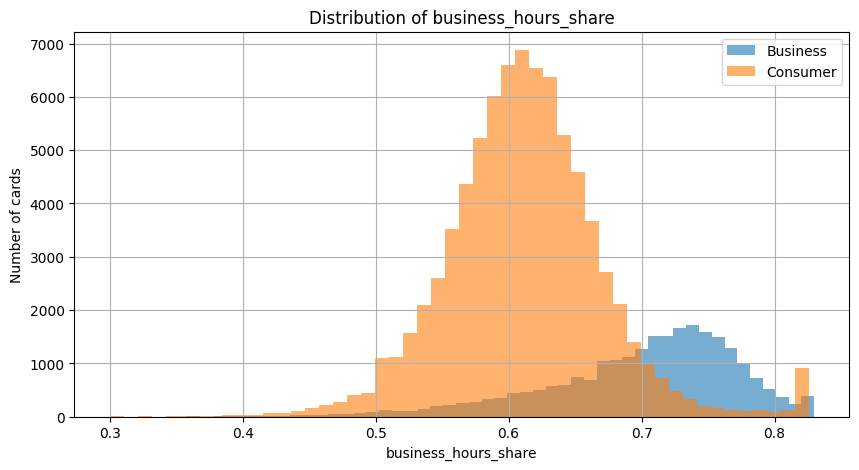

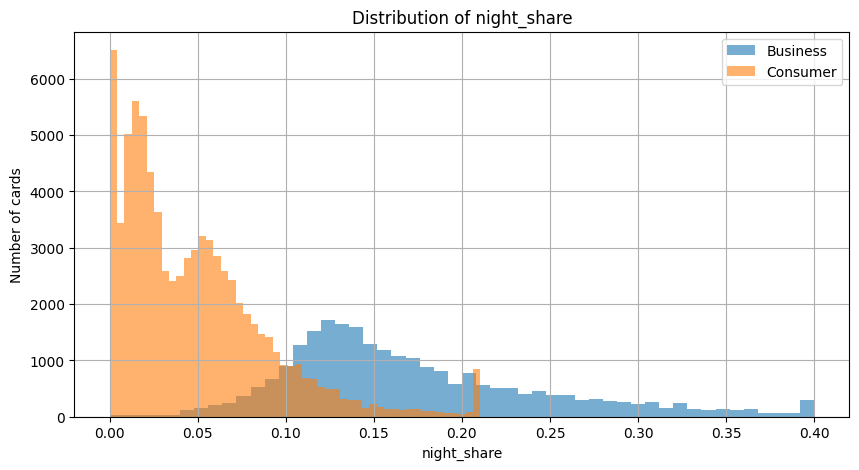

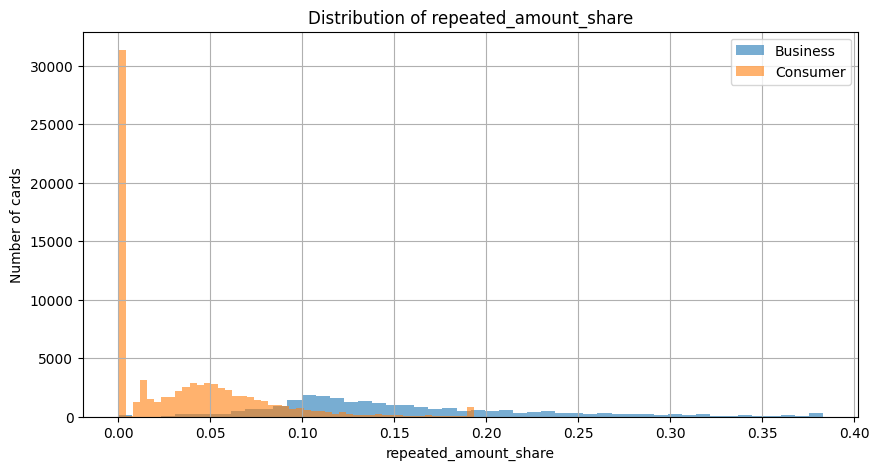

In [67]:
for col in comparison_features:
    plot_card_feature_distribution(business_card_features, consumer_card_features, col)

### Summary

The data is clean — no missing values, no duplicates, ready for feature engineering straight away. The key finding: purchase frequency is nearly identical between the two populations, but money, categories, and timing are radically different. Business cards concentrate larger amounts on a narrow set of merchants (advertising, cloud, B2B services), frequently pay the same recurring amounts (subscriptions and suppliers), are barely active on weekends, and their foreign spend goes to Google and AWS rather than tourism. Consumers are the opposite: small amounts spread across many merchants, a 7-day-a-week rhythm, and foreign transactions that look like shopping and travel. After the hour-of-day fix, an additional strong signal emerged — business cards are nearly 4× more active during night hours (00-06) than consumers, reflecting automated overnight billing of ad platforms, cloud services, and subscriptions. 

Feature engineering should focus on these patterns: money, MCC composition, concentration, regularity, and time-of-day shares (especially night activity and weekends). Transaction count on its own carries almost no signal and should not be used as a standalone feature.

## Feature Engineering

The previous stage produced `business_card_features` and `consumer_card_features` with the base set of card-level features (amounts, activity, merchant/MCC diversity, time, regularity). This section adds the engineered features identified as high-impact during EDA:

- **B2B-MCC share** (categorical signal from MCC composition)
- **Money-shape features** (percentiles, mean/median ratio, large-transaction share)
- **Full Herfindahl-Hirschman concentration** for merchants and MCCs
- **Recurring features** derived from the raw `is_recurring` flag
- **Foreign-share features** (overall, US, Ireland) — captures the B2B-vendor geography pattern
- **Merchants-reference enrichment** (recurring-capable share, merchant-country shares)

All blocks are applied **separately** to the business and consumer transaction frames, and the results are merged into the existing card-level tables. The two output frames are guaranteed to share identical columns — a prerequisite for the modelling stage.

### B2B-MCC dictionary

The MCC codes below are the strictly-business categories from the EDA top-20 business MCCs. Mixed-purpose codes (hotels 7011, airlines 4511, telecom 4814) are excluded to keep the signal clean.

In [68]:
B2B_MCC = {
    "7311",  # advertising (Google/Meta/TikTok Ads)
    "7372",  # cloud / software (AWS, Azure)
    "5968",  # subscription merchants
    "4816",  # digital / information services
    "7399",  # B2B services (other)
    "5045",  # computers & peripherals (wholesale)
    "7392",  # consulting / management
    "4214",  # freight transport
    "4215",  # courier
    "5046",  # commercial equipment
    "5111",  # stationery & office supplies
    "5199",  # nondurable goods (wholesale)
    "5099",  # durable goods (wholesale)
    "8931",  # accounting / auditing
    "7379",  # IT services
}

LARGE_TXN_THRESHOLD = 1_000_000   # KZT — flag a single transaction as 'large'

### Feature blocks

Each block takes a transaction-level DataFrame and returns a card-level table keyed by `card_number`. The blocks are pure functions — applied identically to business and consumer.

In [69]:
def b2b_mcc_features(df, mcc_col="mcc", amount_col="transaction_amount_kzt"):
    """Share of card's transactions and turnover going to B2B MCC categories,
    and number of distinct B2B categories the card touches."""
    df = df.copy()
    df["_is_b2b"] = df[mcc_col].astype(str).isin(B2B_MCC)

    total_amount = df.groupby("card_number")[amount_col].sum()
    b2b_amount   = df.loc[df["_is_b2b"]].groupby("card_number")[amount_col].sum()

    return pd.DataFrame({
        "b2b_txn_share":    df.groupby("card_number")["_is_b2b"].mean(),
        "b2b_amount_share": (b2b_amount / total_amount).fillna(0.0),
        "n_b2b_mcc":        (df.loc[df["_is_b2b"]]
                              .groupby("card_number")[mcc_col]
                              .nunique()
                              .reindex(total_amount.index)
                              .fillna(0)
                              .astype(int)),
    }).reset_index()

This function computes **B2B-related behavioral features** for each card based on MCC categories.

It first flags transactions belonging to predefined B2B MCC codes, then aggregates data at the card level. 

For each card, it calculates the share of B2B transactions, the share of total spending attributed to B2B categories, and the number of distinct B2B MCC categories used. The output is a feature table that captures how strongly each card is associated with business-related spending.

In [70]:
def money_shape_features(df, amount_col="transaction_amount_kzt",
                         large_thr=LARGE_TXN_THRESHOLD):
    """Long-tail and shape descriptors of the card's spending distribution:
    high percentiles, mean/median ratio (skewness proxy), and large-transaction counts."""
    g = df.groupby("card_number")[amount_col]

    out = pd.DataFrame({
        "p90_amount": g.quantile(0.90),
        "p95_amount": g.quantile(0.95),
        "p99_amount": g.quantile(0.99),
    }).reset_index()

    means   = g.mean()
    medians = g.median().replace(0, np.nan)
    out["mean_to_median_ratio"] = (
        (means / medians)
        .reindex(out["card_number"].values)
        .fillna(1.0)
        .values
    )

    df = df.copy()
    df["_is_large"] = df[amount_col] >= large_thr
    large_stats = df.groupby("card_number").agg(
        large_txn_count=("_is_large", "sum"),
        large_txn_share=("_is_large", "mean"),
    ).reset_index()

    return out.merge(large_stats, on="card_number", how="left")

This function extracts **“money shape”** features that describe the distribution of spending behavior per card. 

It calculates high-percentile transaction amounts (P90, P95, P99) to capture the long-tail of spending, and computes the mean-to-median ratio as a proxy for spending skewness. 

In addition, it identifies large transactions based on a predefined threshold and derives both the count and share of such transactions for each card. 

The resulting feature set characterizes how uneven, heavy-tailed, and large-transaction-driven a card’s spending pattern is.

In [71]:
def hhi_features(df, merchant_col="merchant_id", mcc_col="mcc"):
    """Full Herfindahl-Hirschman concentration index: sum of squared shares.
    HHI = 1 means card spends entirely at one place; HHI ≈ 0 means spread thin.
    This generalises the existing `top_*_share` features."""
    def _hhi(d, key):
        counts = d.groupby(["card_number", key]).size()
        totals = counts.groupby(level=0).sum()
        shares = counts / totals
        return (shares ** 2).groupby(level=0).sum()

    return pd.DataFrame({
        "merchant_hhi": _hhi(df, merchant_col),
        "mcc_hhi":      _hhi(df, mcc_col),
    }).reset_index()

This function computes **Herfindahl–Hirschman Index (HHI)** based concentration features for each card. 

It measures how concentrated spending is across merchants and MCC categories by summing squared transaction shares. 

A higher HHI (closer to 1) indicates that spending is highly concentrated on a single merchant or category, while a lower value indicates more diversified spending across many merchants or MCCs. 

The function returns two features per card: merchant-level concentration **(merchant_hhi)** and category-level concentration **(mcc_hhi)**.

In [72]:
def recurring_features(df, amount_col="transaction_amount_kzt",
                       recurring_col="is_recurring"):
    """Share of card's transactions / turnover flagged as recurring.
    Complements the `repeated_amount_share` heuristic with the explicit flag
    from the source data."""
    df = df.copy()
    df[recurring_col] = df[recurring_col].astype(bool)

    total_amt = df.groupby("card_number")[amount_col].sum()
    rec_amt   = df.loc[df[recurring_col]].groupby("card_number")[amount_col].sum()

    return pd.DataFrame({
        "recurring_share":        df.groupby("card_number")[recurring_col].mean(),
        "recurring_amount_share": (rec_amt / total_amt).fillna(0.0),
    }).reset_index()

This function computes **recurring payment features** at the card level using an explicit recurrence flag from the data. 

It calculates the share of transactions marked as recurring and the share of total spending attributed to recurring payments. 

These two metrics capture how much of a card’s activity is driven by subscriptions or automated billing flows, complementing heuristic-based indicators of repeated transaction amounts.

In [73]:
def geography_share_features(df, country_col="country"):
    """Overall foreign share plus targeted shares for the two countries that
    dominated business foreign spend in EDA: US (AWS, cloud) and Ireland
    (Google Ads, Meta Ads)."""
    df = df.copy()
    df["_is_foreign"] = df[country_col] != "Kazakhstan"
    df["_is_us"]      = df[country_col] == "US"
    df["_is_ireland"] = df[country_col] == "Ireland"

    return df.groupby("card_number").agg(
        foreign_share=("_is_foreign", "mean"),
        us_share=("_is_us", "mean"),
        ireland_share=("_is_ireland", "mean"),
    ).reset_index()

This function computes **geography-based spending features** at the card level. 

It first flags whether each transaction is domestic or foreign, and additionally identifies transactions made in the United States and Ireland, which are key locations for major B2B services (e.g., cloud and advertising platforms). 

It then aggregates these indicators per card to calculate the overall foreign spending share, as well as the specific shares attributed to US and Ireland. 

The resulting features capture both general cross-border activity and exposure to business-relevant geographies.

In [74]:
def merchant_ref_features(df, merchants_ref, merchant_col="merchant_id"):
    """Enrich transactions with the merchants reference table:
    - recurring_capable_share — share of transactions at merchants that *can* run recurring billing
    - foreign / US / Ireland merchant shares — based on merchant_country (where the merchant is registered),
      which is different from `country` (where the transaction happened)"""
    enriched = df[["card_number", merchant_col]].merge(
        merchants_ref[[merchant_col, "merchant_country", "recurring_capable"]],
        on=merchant_col,
        how="left",
    )
    enriched["_capable"]   = enriched["recurring_capable"].fillna(False).astype(bool)
    enriched["_m_foreign"] = enriched["merchant_country"] != "Kazakhstan"
    enriched["_m_us"]      = enriched["merchant_country"] == "US"
    enriched["_m_ireland"] = enriched["merchant_country"] == "Ireland"

    return enriched.groupby("card_number").agg(
        recurring_capable_share=("_capable",   "mean"),
        foreign_merchant_share =("_m_foreign", "mean"),
        us_merchant_share      =("_m_us",      "mean"),
        ireland_merchant_share =("_m_ireland", "mean"),
    ).reset_index()

This function enriches transaction data using a **merchant reference table** and computes merchant-level behavioral features per card. 

It first joins each transaction with merchant metadata, including merchant country and whether the merchant supports recurring billing. 

It then creates binary indicators for recurring-capable merchants and for merchants registered in the US, Ireland, or outside Kazakhstan. 

Finally, it aggregates these indicators at the card level to produce the share of transactions at recurring-capable merchants, as well as geographic exposure based on merchant registration location. 

These features capture structural differences in payment infrastructure usage beyond transaction-level geography.

### Apply blocks and merge

One wrapper applies every block to a transaction frame and merges the results into the existing card-level table.

In [75]:
def add_engineered_features(card_features, tx_df, merchants_ref):
    """Apply all FE blocks to `tx_df` and merge into the existing card-level frame."""
    out = card_features.copy()

    blocks = [
        b2b_mcc_features(tx_df),
        money_shape_features(tx_df),
        hhi_features(tx_df),
        recurring_features(tx_df),
        geography_share_features(tx_df),
        merchant_ref_features(tx_df, merchants_ref),
    ]

    for blk in blocks:
        out = out.merge(blk, on="card_number", how="left")

    # Cards with no B2B / recurring / foreign activity get NaN from the joins -> 0
    return out.fillna(0)


business_card_features = add_engineered_features(business_card_features, business_df, merchants)
consumer_card_features = add_engineered_features(consumer_card_features, consumer_df, merchants)

print("Business card-level features:", business_card_features.shape)
print("Consumer card-level features:", consumer_card_features.shape)

Business card-level features: (25000, 47)
Consumer card-level features: (80000, 47)


This function **applies all feature engineering blocks** to the transaction dataset and merges the resulting card-level features into an existing feature table. 

It sequentially computes B2B behavior features, spending distribution (“money shape”) features, concentration (HHI) metrics, recurring payment features, transaction geography shares, and merchant reference-based features. 

Each feature block is aggregated at the card_number level and merged into the base dataset using left joins. 

Missing values resulting from the merges (e.g., no B2B or foreign activity) are replaced with zero. 

The function outputs a fully enriched card-level feature set for both business and consumer datasets, ready for modeling or analysis.

### Sanity checks

The business and consumer frames must share **identical columns** for the one-class model. We also confirm no NaN values slipped through, and we look at the new feature medians to verify they point in the expected direction.

In [76]:
# Identical schema check
biz_cols = set(business_card_features.columns)
con_cols = set(consumer_card_features.columns)
print("Columns identical:", biz_cols == con_cols)
if biz_cols != con_cols:
    print("  business only:", biz_cols - con_cols)
    print("  consumer only:", con_cols - biz_cols)

# Null check
print("Business NaNs:", int(business_card_features.isna().sum().sum()))
print("Consumer NaNs:", int(consumer_card_features.isna().sum().sum()))

# Total feature count
print("Total features (excluding card_number):",
      business_card_features.shape[1] - 1)

Columns identical: True
Business NaNs: 0
Consumer NaNs: 0
Total features (excluding card_number): 46


This code performs basic validation of the engineered feature datasets for business and consumer cards.

It first checks whether both datasets have identical feature schemas by comparing their column sets, and reports any columns that are present in only one of them. 

It then evaluates data completeness by counting total missing values (NaNs) in each dataset. 

Finally, it prints the total number of engineered features per card, excluding the identifier column card_number, to confirm the final feature dimensionality.

In [77]:
# Quick direction check on the new features
new_feats = [
    "b2b_txn_share", "b2b_amount_share", "n_b2b_mcc",
    "p90_amount", "p95_amount", "mean_to_median_ratio",
    "large_txn_share", "merchant_hhi", "mcc_hhi",
    "recurring_share", "recurring_amount_share",
    "foreign_share", "us_share", "ireland_share",
    "recurring_capable_share", "foreign_merchant_share",
    "us_merchant_share", "ireland_merchant_share",
]

fe_summary = pd.DataFrame({
    "feature":         new_feats,
    "business_median": [business_card_features[c].median() for c in new_feats],
    "consumer_median": [consumer_card_features[c].median() for c in new_feats],
})
fe_summary["b_to_c_ratio"] = (
    fe_summary["business_median"] /
    fe_summary["consumer_median"].replace(0, np.nan)
)
display(fe_summary.round(4))

,feature,business_median,consumer_median,b_to_c_ratio
0,b2b_txn_share,0.6029,0.0000,NaN
1,b2b_amount_share,0.8220,0.0000,NaN
2,n_b2b_mcc,7.0000,0.0000,NaN
3,p90_amount,369969.5000,60852.2000,6.0798
4,p95_amount,526319.5000,100822.8250,5.2202
5,mean_to_median_ratio,1.8511,2.5406,0.7286
6,large_txn_share,0.0083,0.0000,NaN
7,merchant_hhi,0.1923,0.0455,4.2263
8,mcc_hhi,0.1930,0.0519,3.7183
9,recurring_share,0.1343,0.0000,NaN


This code performs a **quick sanity and signal-strength check** on newly engineered features by comparing their distributions between business and consumer card segments.

It constructs a summary table where, for each feature, it computes the median value separately for business and consumer datasets. 

It then calculates the business-to-consumer median ratio as a simple measure of directional separation between the two groups. 

The resulting table is used to validate whether the engineered features behave as expected (i.e., whether they meaningfully differentiate business vs. consumer spending patterns) before proceeding to modeling.

### Drop identifier / leakage columns from the modelling matrix

These stay attached to the frame for downstream interpretation, but should not be passed to the model:
- `card_number` — identifier
- `first_transaction`, `last_transaction` — raw timestamps, not features

The `target` column added later in the modelling stage is the population tag, not a model feature.

In [78]:
EXCLUDE_FROM_MODEL = [
    "card_number",
    "first_transaction",
    "last_transaction",
]

model_feature_cols = [
    c for c in business_card_features.columns
    if c not in EXCLUDE_FROM_MODEL
]

print(f"Number of model features: {len(model_feature_cols)}")
print("Model features:")
for c in model_feature_cols:
    print(f"  - {c}")

Number of model features: 44
Model features:
  - total_amount
  - mean_amount
  - median_amount
  - std_amount
  - max_amount
  - min_amount
  - transaction_count
  - active_days
  - period_days
  - transactions_per_active_day
  - transactions_per_period_day
  - unique_merchants
  - top_merchant_share
  - unique_mcc
  - top_mcc_share
  - unique_countries
  - weekend_share
  - business_hours_share
  - night_share
  - avg_transaction_hour
  - std_transaction_hour
  - avg_days_between_txn
  - std_days_between_txn
  - repeated_amount_share
  - b2b_txn_share
  - b2b_amount_share
  - n_b2b_mcc
  - p90_amount
  - p95_amount
  - p99_amount
  - mean_to_median_ratio
  - large_txn_count
  - large_txn_share
  - merchant_hhi
  - mcc_hhi
  - recurring_share
  - recurring_amount_share
  - foreign_share
  - us_share
  - ireland_share
  - recurring_capable_share
  - foreign_merchant_share
  - us_merchant_share
  - ireland_merchant_share


This code defines the final set of features to be used for modeling. 

It explicitly excludes non-informative or identifier-like columns such as card_number, first_transaction, and last_transaction, since they do not carry predictive signal and may introduce leakage or noise.

After filtering, it constructs a list of all remaining columns as model_feature_cols, which represent the engineered input features for the model. The code then prints the total number of selected features and lists them individually for verification and transparency of the final feature set.

### Save final card-level datasets

The modelling stage will load these two files.

In [79]:
business_card_features.to_parquet(
    "business_card_features.parquet", index=False, compression="snappy"
)
consumer_card_features.to_parquet(
    "consumer_card_features.parquet", index=False, compression="snappy"
)
print("Saved:")
print(f"  business_card_features.parquet — {business_card_features.shape}")
print(f"  consumer_card_features.parquet — {consumer_card_features.shape}")

Saved:
  business_card_features.parquet — (25000, 47)
  consumer_card_features.parquet — (80000, 47)


In [80]:
business_numeric = business_card_features.select_dtypes(
    include=['int64', 'float64', 'int32', 'float32']
)

consumer_numeric = consumer_card_features.select_dtypes(
    include=['int64', 'float64', 'int32', 'float32']
)

print("Business numeric shape:", business_numeric.shape)
print("Consumer numeric shape:", consumer_numeric.shape)

Business numeric shape: (25000, 44)
Consumer numeric shape: (80000, 44)


In [81]:
business_corr_matrix = business_numeric.corr()

print("Business correlation matrix shape:",
      business_corr_matrix.shape)

display(business_corr_matrix.head())

Business correlation matrix shape: (44, 44)


,total_amount,mean_amount,median_amount,std_amount,max_amount,min_amount,transaction_count,active_days,period_days,transactions_per_active_day,...,mcc_hhi,recurring_share,recurring_amount_share,foreign_share,us_share,ireland_share,recurring_capable_share,foreign_merchant_share,us_merchant_share,ireland_merchant_share
total_amount,1.000000,0.353019,0.167042,0.480396,0.515845,-0.026981,0.582378,0.560591,0.255141,0.532237,...,0.120755,-0.407351,-0.529821,-0.284879,-0.196904,0.016478,-0.019050,-0.000361,-0.090458,0.124359
mean_amount,0.353019,1.000000,0.842241,0.712080,0.375126,0.414811,-0.480280,-0.494639,-0.269697,-0.435570,...,-0.078964,0.501077,-0.045467,0.382938,0.129098,0.258619,0.249828,0.219070,0.033814,0.242348
median_amount,0.167042,0.842241,1.000000,0.368587,0.109626,0.447433,-0.536651,-0.552609,-0.305030,-0.490993,...,-0.102400,0.594481,0.000649,0.442471,0.218402,0.219720,0.286924,0.271085,0.121011,0.188386
std_amount,0.480396,0.712080,0.368587,1.000000,0.869998,0.149288,-0.158162,-0.165415,-0.085774,-0.138021,...,-0.009185,0.156878,-0.186077,0.135767,-0.015006,0.169370,0.141706,0.113263,-0.049873,0.213918
max_amount,0.515845,0.375126,0.109626,0.869998,1.000000,0.011457,0.123718,0.118162,0.057228,0.115153,...,0.058057,-0.092392,-0.322600,-0.059012,-0.081254,0.068120,0.069861,0.058580,-0.053060,0.146954


In [82]:
consumer_corr_matrix = consumer_numeric.corr()

print("Consumer correlation matrix shape:",
      consumer_corr_matrix.shape)

display(consumer_corr_matrix.head())

Consumer correlation matrix shape: (44, 44)


,total_amount,mean_amount,median_amount,std_amount,max_amount,min_amount,transaction_count,active_days,period_days,transactions_per_active_day,...,mcc_hhi,recurring_share,recurring_amount_share,foreign_share,us_share,ireland_share,recurring_capable_share,foreign_merchant_share,us_merchant_share,ireland_merchant_share
total_amount,1.000000,0.816229,0.677620,0.845938,0.817782,0.371677,0.386144,0.310141,0.132102,0.417315,...,0.306776,0.048672,0.010383,0.714233,0.367196,0.229573,0.227358,0.271985,0.137041,0.231779
mean_amount,0.816229,1.000000,0.934721,0.906562,0.744395,0.563179,-0.026060,-0.080916,-0.040969,0.033179,...,0.554440,0.207025,0.121659,0.579836,0.319824,0.277123,0.332047,0.367048,0.213169,0.302858
median_amount,0.677620,0.934721,1.000000,0.736381,0.556900,0.581709,-0.096248,-0.141909,-0.065957,-0.045382,...,0.660608,0.236486,0.186550,0.441742,0.252969,0.291151,0.357771,0.388377,0.229830,0.324768
std_amount,0.845938,0.906562,0.736381,1.000000,0.937780,0.445195,0.084544,0.027572,0.008059,0.143543,...,0.353403,0.130392,0.039071,0.636907,0.342340,0.202948,0.242653,0.278896,0.151474,0.230131
max_amount,0.817782,0.744395,0.556900,0.937780,1.000000,0.325167,0.226525,0.169021,0.071523,0.271317,...,0.209556,0.053828,-0.010246,0.617271,0.323932,0.145652,0.165597,0.201690,0.098748,0.170854


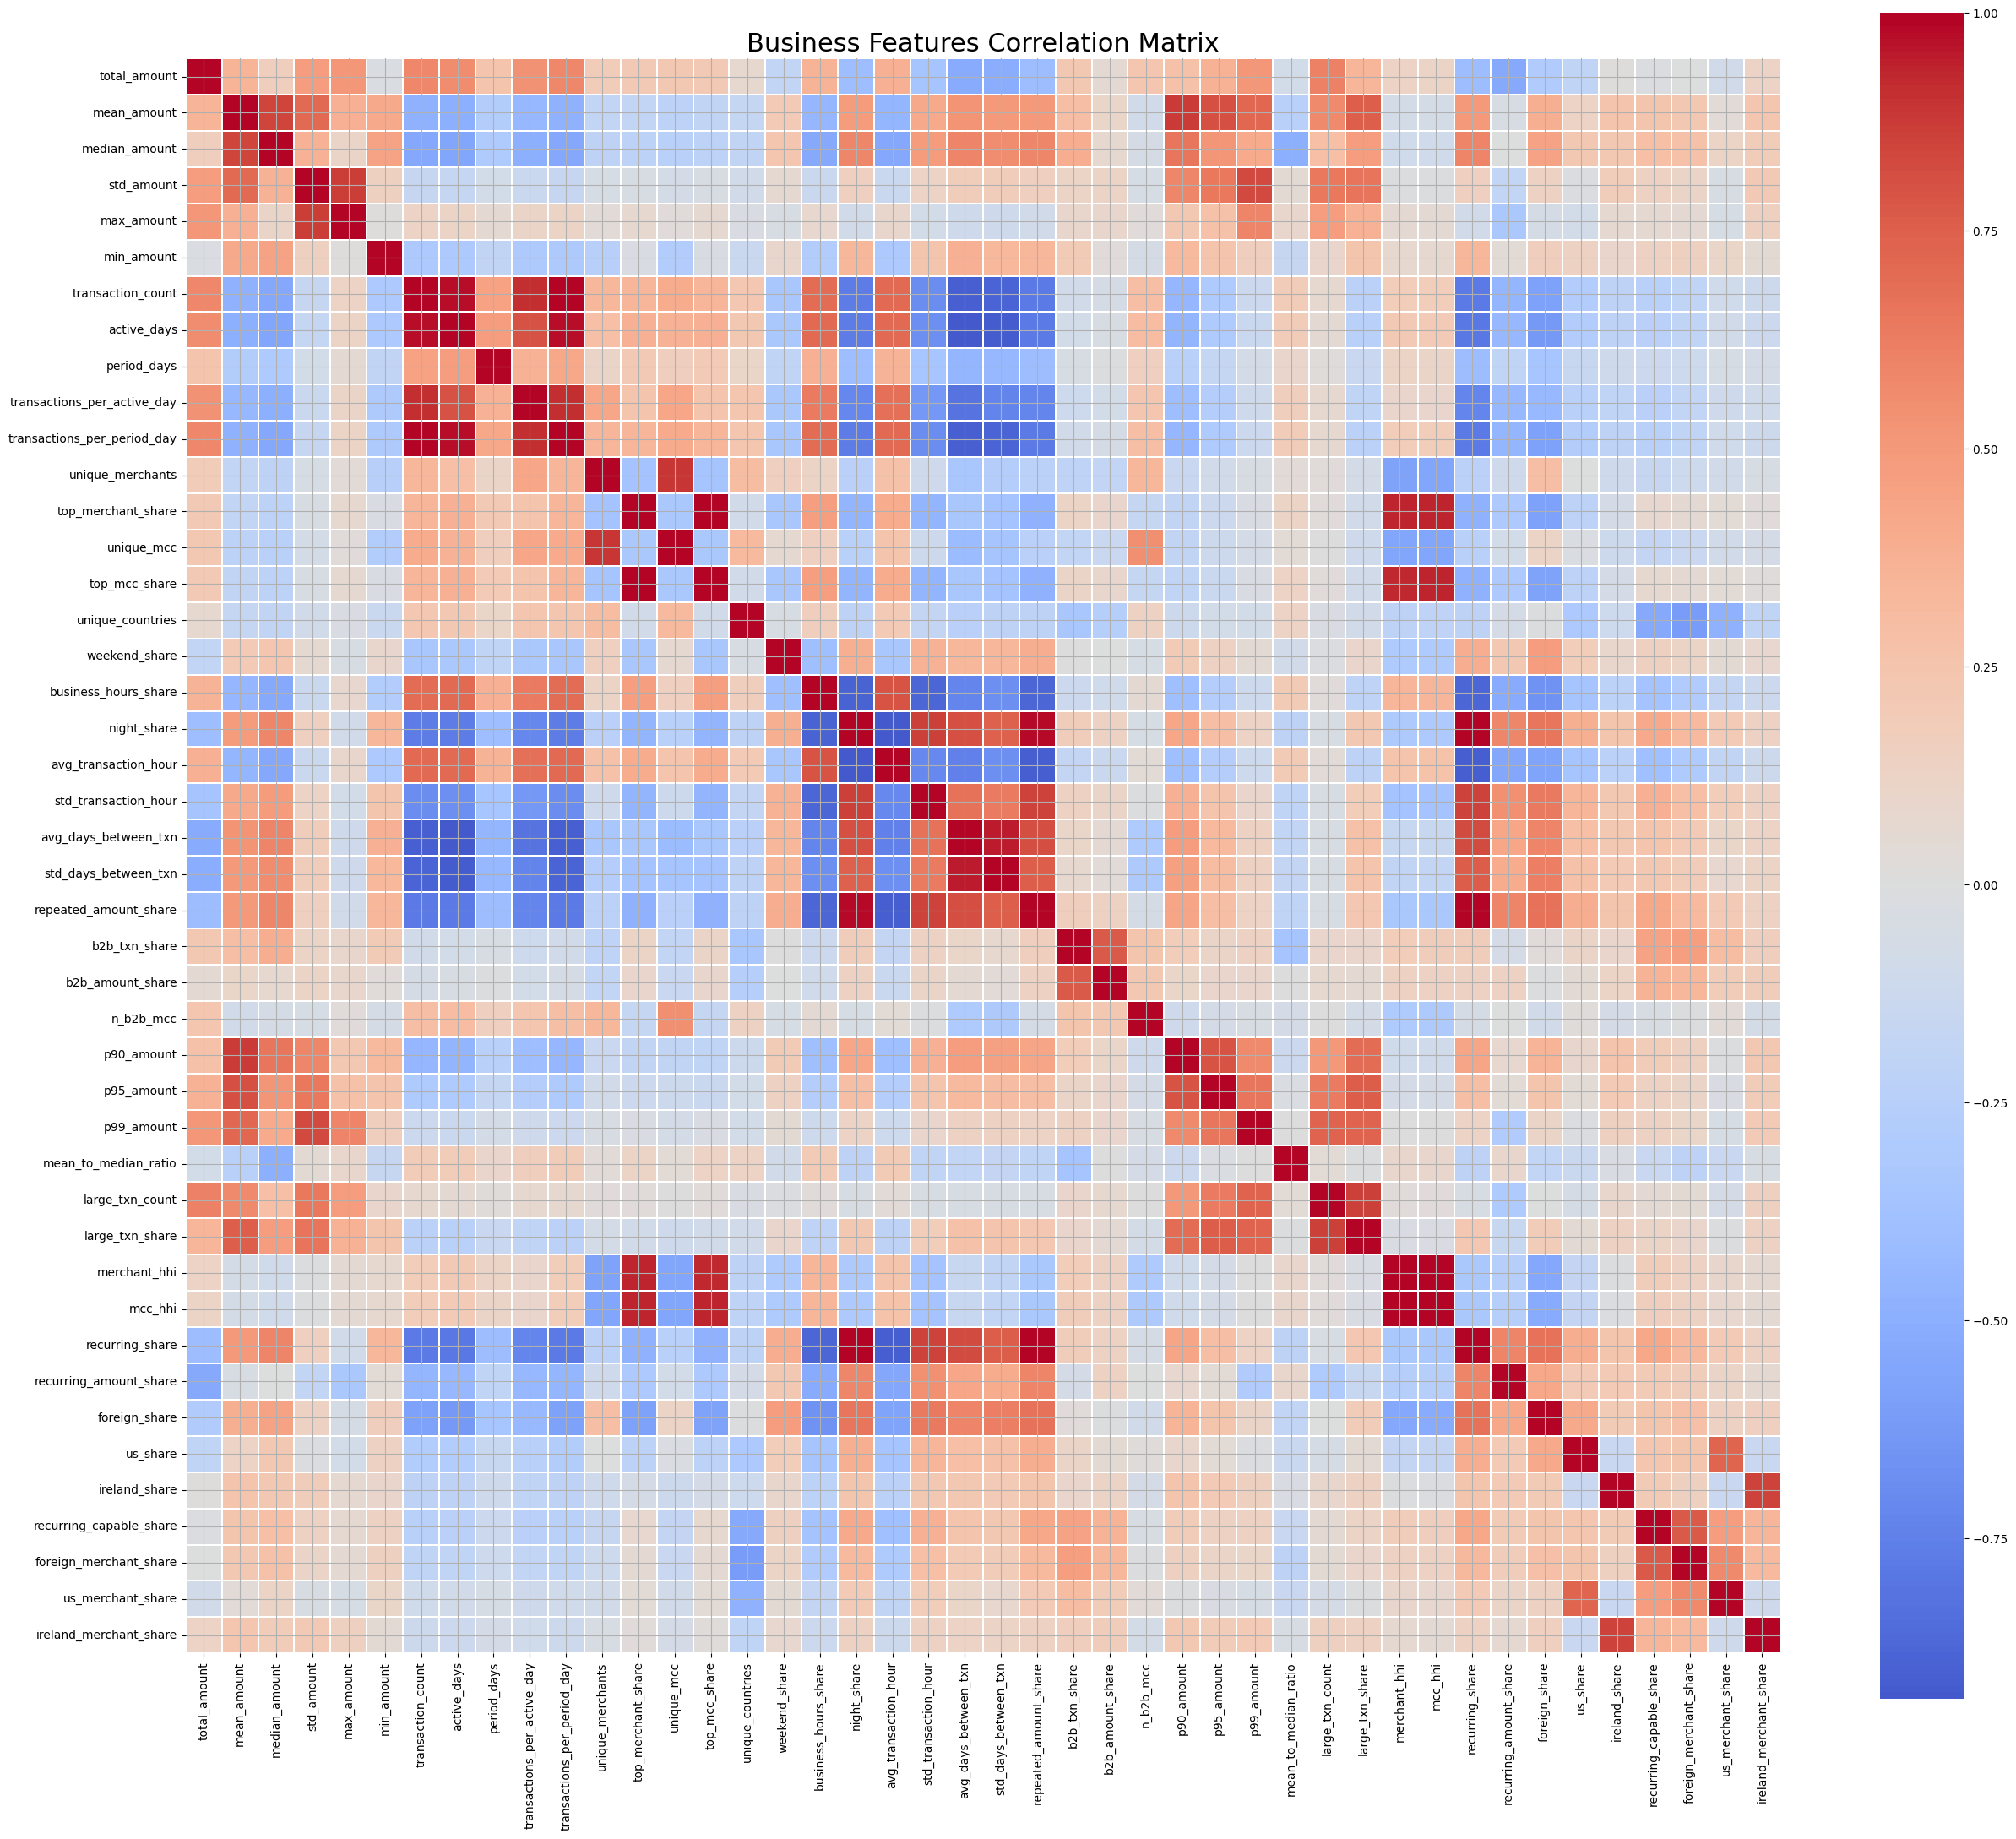

In [83]:
plt.figure(figsize=(26, 22))

sns.heatmap(
    business_corr_matrix,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.2
)

plt.title(
    'Business Features Correlation Matrix',
    fontsize=22
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

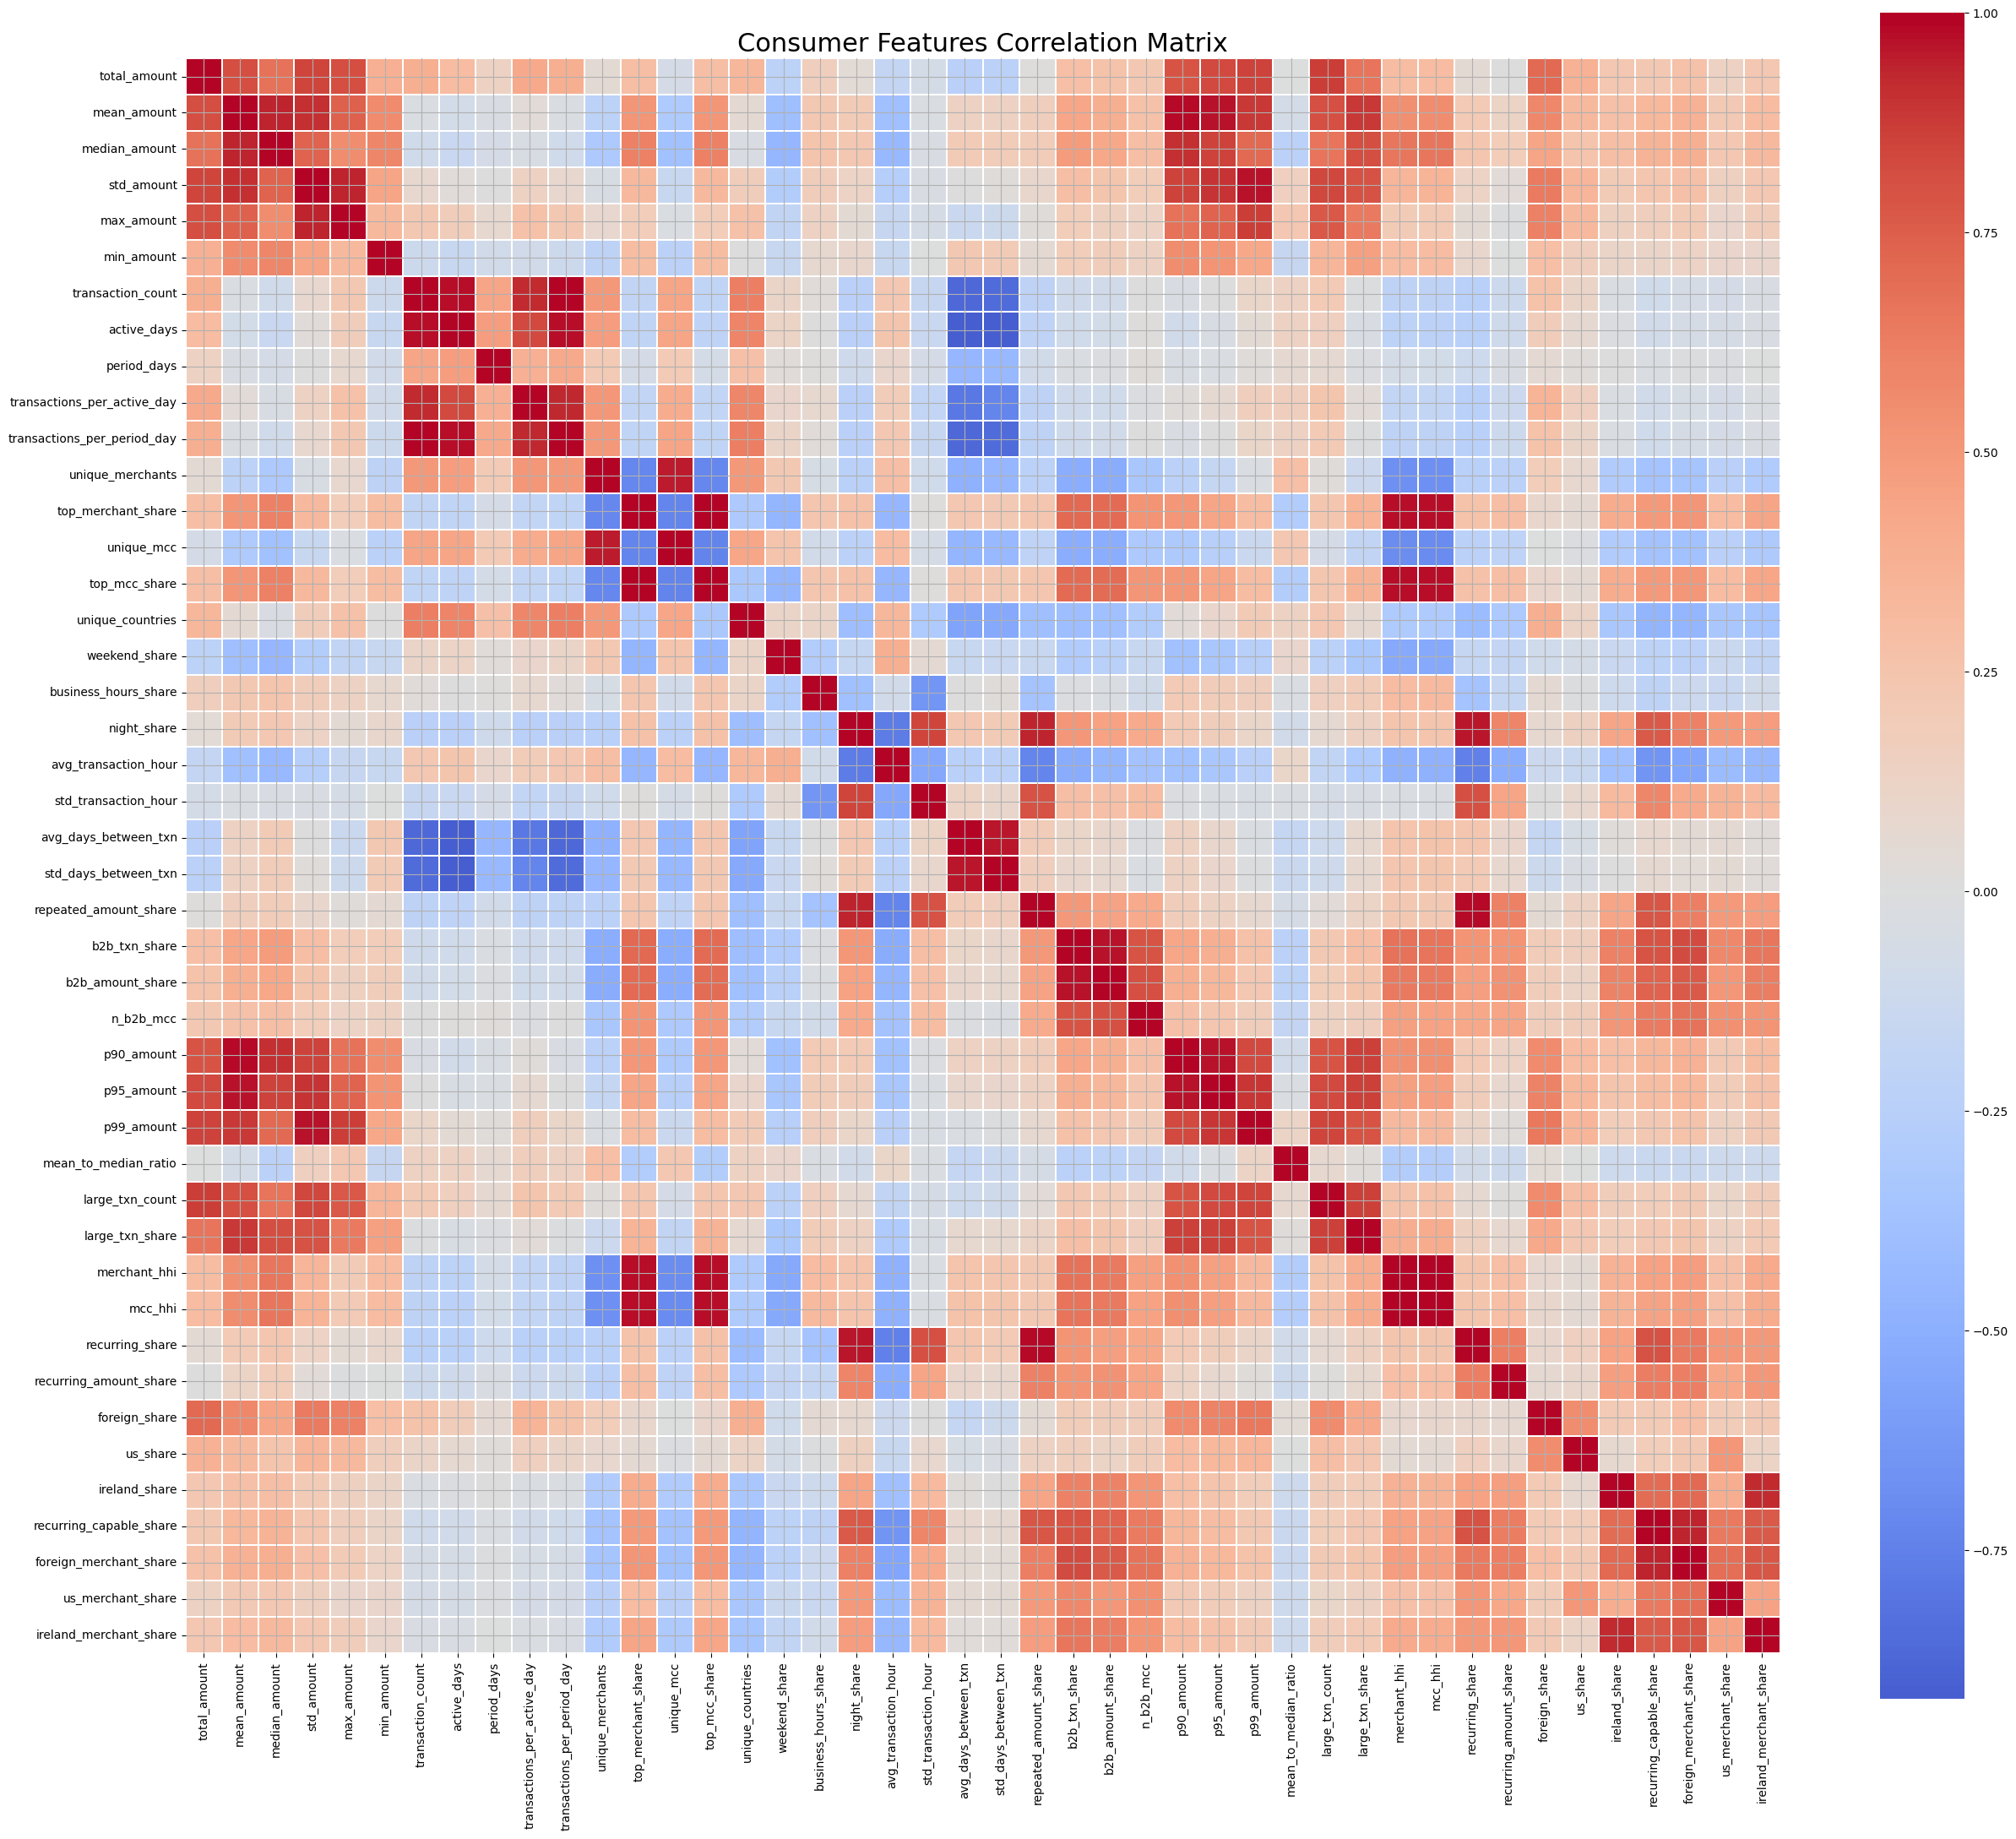

In [84]:
plt.figure(figsize=(26, 22))

sns.heatmap(
    consumer_corr_matrix,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.2
)

plt.title(
    'Consumer Features Correlation Matrix',
    fontsize=22
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [85]:
business_corr_pairs = (
    business_corr_matrix.abs()
    .unstack()
    .sort_values(ascending=False)
)

business_corr_pairs = business_corr_pairs[
    business_corr_pairs < 1
]

business_high_corr = pd.DataFrame(
    business_corr_pairs
).reset_index()

business_high_corr.columns = [
    'feature_1',
    'feature_2',
    'correlation'
]

business_high_corr['pair'] = business_high_corr.apply(
    lambda x: '_'.join(
        sorted([x['feature_1'], x['feature_2']])
    ),
    axis=1
)

business_high_corr = (
    business_high_corr
    .drop_duplicates('pair')
    .drop(columns='pair')
)

business_high_corr = business_high_corr[
    business_high_corr['correlation'] > 0.90
]

business_high_corr = business_high_corr.sort_values(
    by='correlation',
    ascending=False
)

print("TOP HIGH CORRELATIONS — BUSINESS")

display(business_high_corr.head(50))

TOP HIGH CORRELATIONS — BUSINESS


,feature_1,feature_2,correlation
0,transactions_per_period_day,transaction_count,0.999400
2,recurring_share,repeated_amount_share,0.998475
4,top_merchant_share,top_mcc_share,0.998465
6,merchant_hhi,mcc_hhi,0.997718
8,night_share,recurring_share,0.985421
10,repeated_amount_share,night_share,0.983870
12,transaction_count,active_days,0.971519
14,transactions_per_period_day,active_days,0.970091
16,std_days_between_txn,avg_days_between_txn,0.950156
18,avg_days_between_txn,active_days,0.934045


In [86]:
consumer_corr_pairs = (
    consumer_corr_matrix.abs()
    .unstack()
    .sort_values(ascending=False)
)

consumer_corr_pairs = consumer_corr_pairs[
    consumer_corr_pairs < 1
]

consumer_high_corr = pd.DataFrame(
    consumer_corr_pairs
).reset_index()

consumer_high_corr.columns = [
    'feature_1',
    'feature_2',
    'correlation'
]

consumer_high_corr['pair'] = consumer_high_corr.apply(
    lambda x: '_'.join(
        sorted([x['feature_1'], x['feature_2']])
    ),
    axis=1
)

consumer_high_corr = (
    consumer_high_corr
    .drop_duplicates('pair')
    .drop(columns='pair')
)

consumer_high_corr = consumer_high_corr[
    consumer_high_corr['correlation'] > 0.90
]

consumer_high_corr = consumer_high_corr.sort_values(
    by='correlation',
    ascending=False
)

print("TOP HIGH CORRELATIONS — CONSUMER")

display(consumer_high_corr.head(50))

TOP HIGH CORRELATIONS — CONSUMER


,feature_1,feature_2,correlation
0,transactions_per_period_day,transaction_count,0.999469
2,mcc_hhi,merchant_hhi,0.998767
4,top_merchant_share,top_mcc_share,0.994576
6,mean_amount,p90_amount,0.978668
8,recurring_share,repeated_amount_share,0.978084
10,top_merchant_share,merchant_hhi,0.974571
12,mcc_hhi,top_mcc_share,0.972692
14,top_mcc_share,merchant_hhi,0.972055
16,active_days,transaction_count,0.971877
18,mcc_hhi,top_merchant_share,0.971458


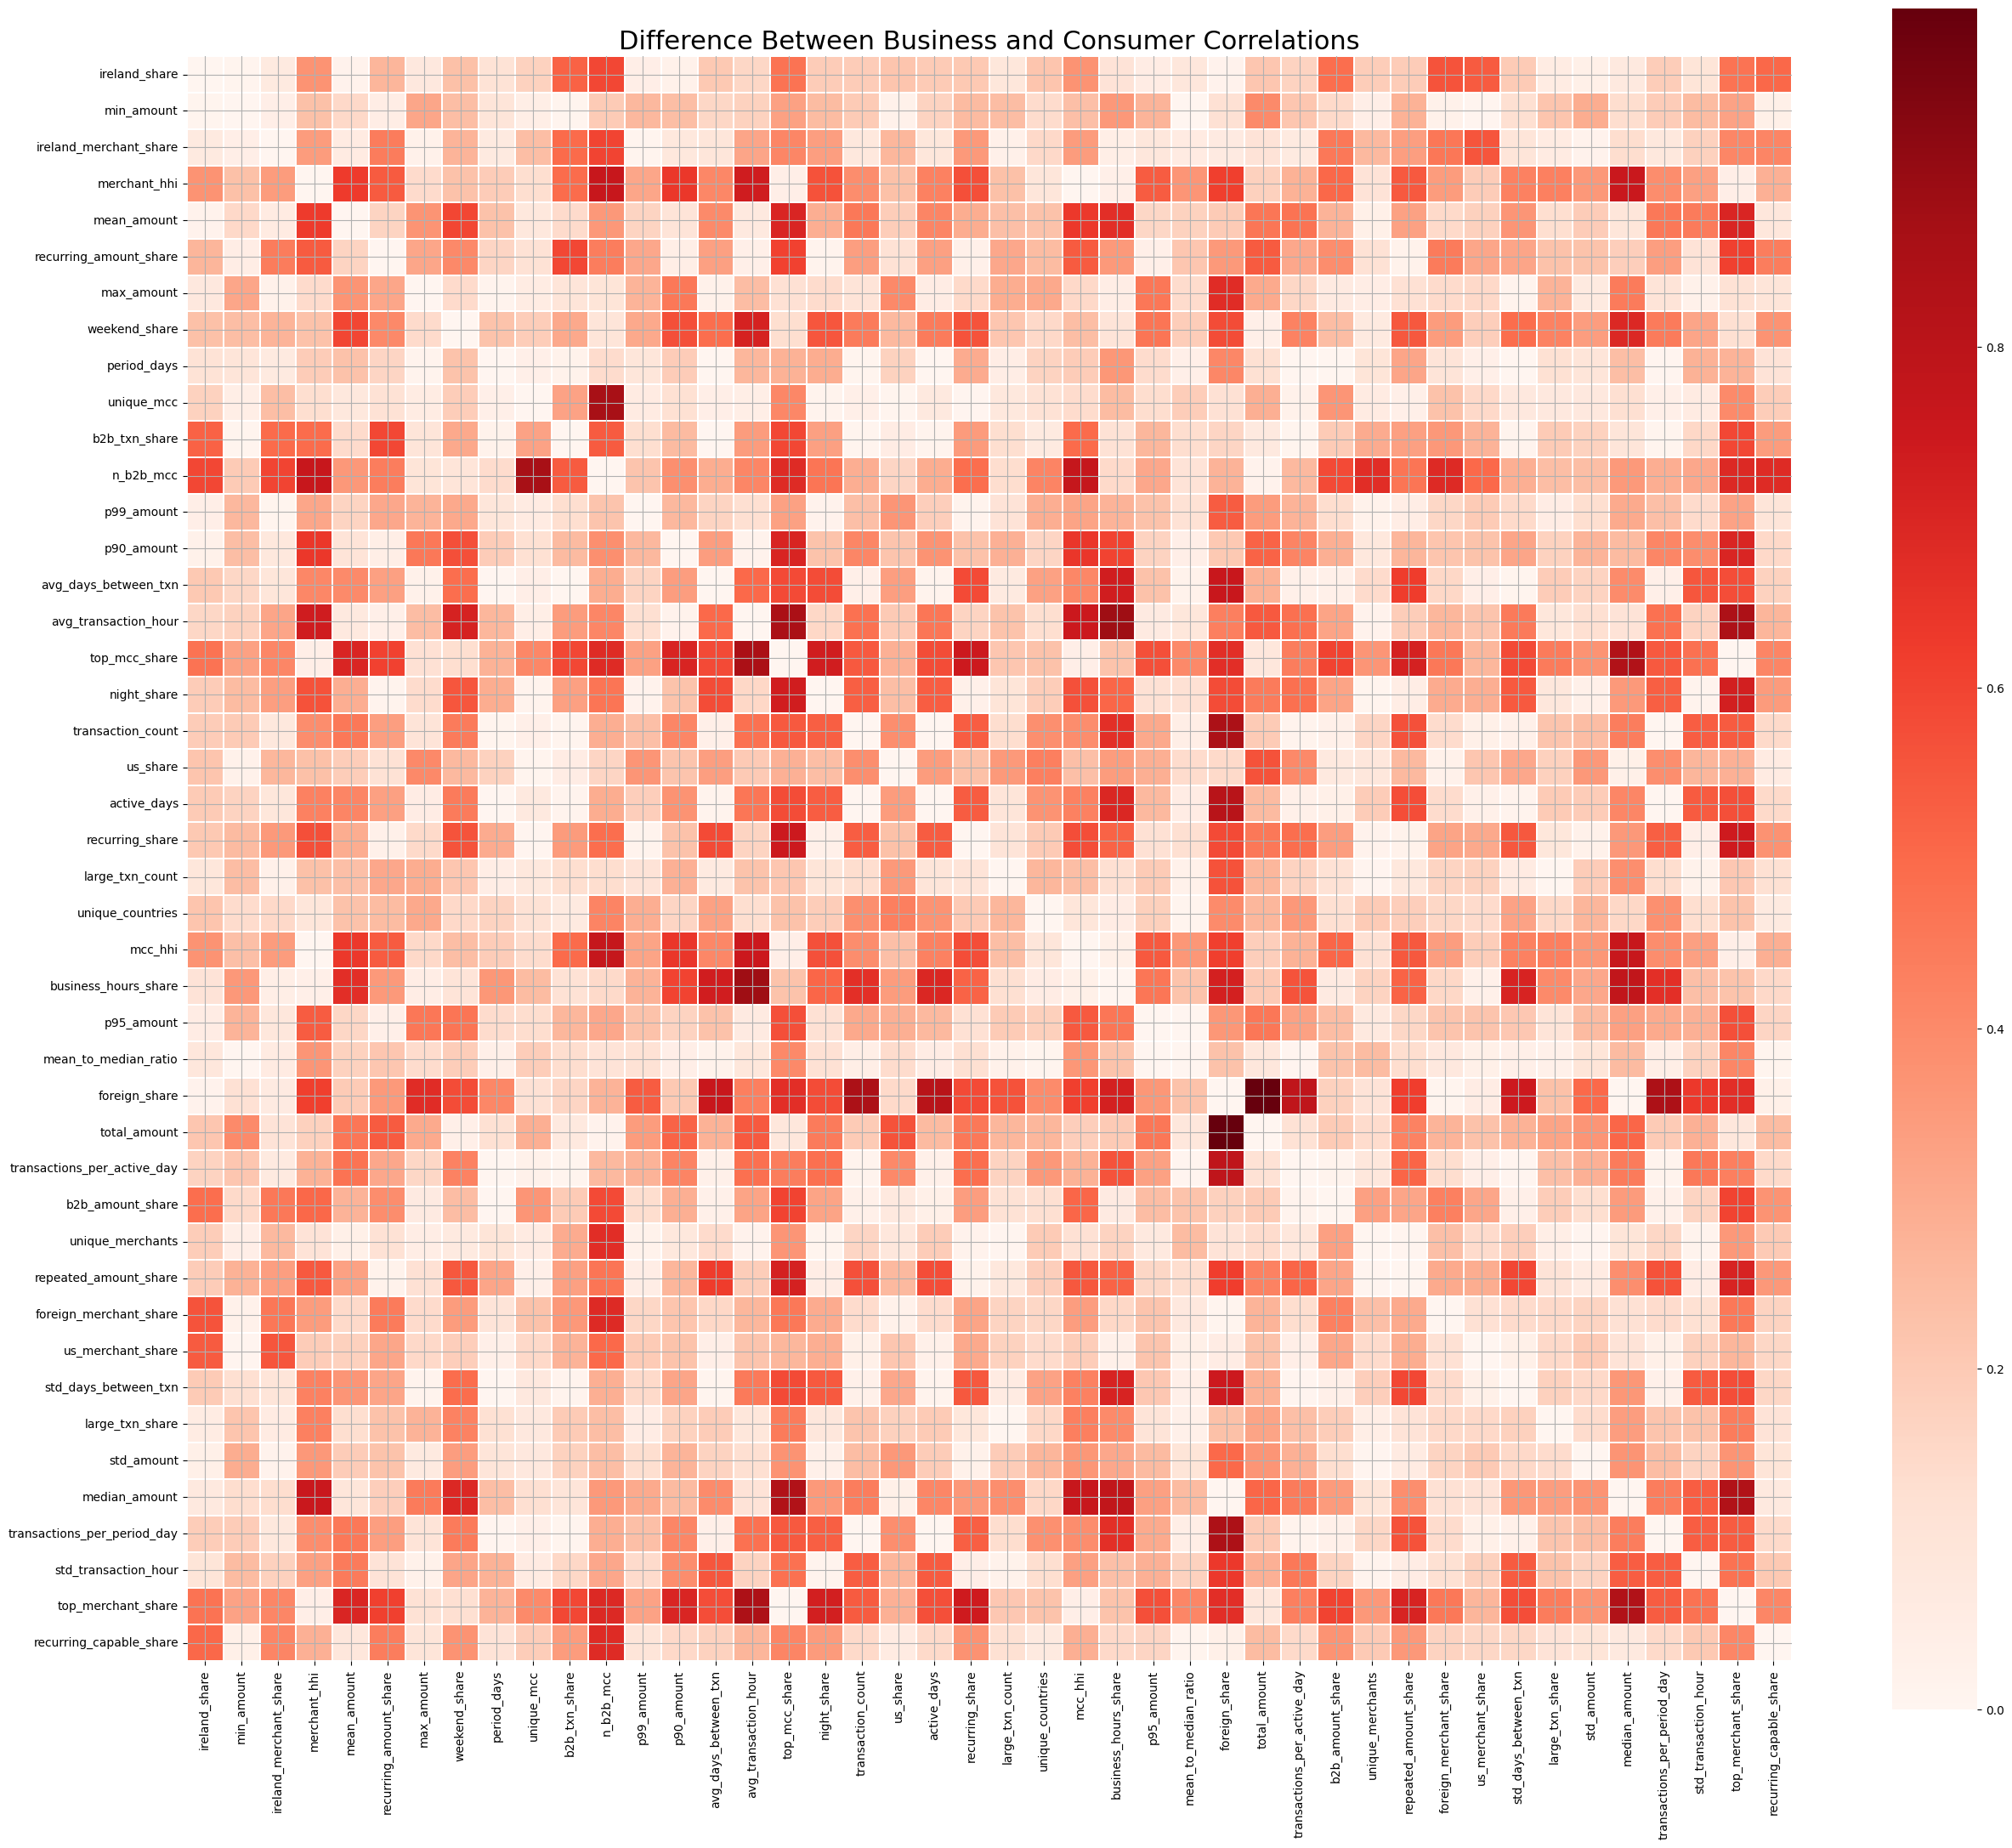

In [87]:
common_features = list(
    set(business_numeric.columns)
    & set(consumer_numeric.columns)
)

business_corr_common = business_numeric[
    common_features
].corr()

consumer_corr_common = consumer_numeric[
    common_features
].corr()

corr_difference = (
    business_corr_common - consumer_corr_common
).abs()

plt.figure(figsize=(26, 22))

sns.heatmap(
    corr_difference,
    cmap='Reds',
    square=True,
    linewidths=0.2
)

plt.title(
    'Difference Between Business and Consumer Correlations',
    fontsize=22
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## ML Modeling 

The workflow strictly follows the one-class logic. Consumers are **never** used during training or hyperparameter calibration. They only enter at the very last step, when the final tuned model is applied to score them.

**Pipeline:**

1. **Split** the business population 80/20: 80% for training, 20% held out as a self-test set. Consumers stay untouched.
2. **Preprocess**: log-transform monetary features; fit `StandardScaler` on the 80% training business only.
3. **Train** an Isolation Forest on the 80% training business — the model learns "what a typical business card looks like".
4. **Self-test** on the 20% holdout business: does the model recognize cards it has never seen as business-like? If yes, the model generalizes within the business distribution.
5. **Calibrate hyperparameters** by repeating steps 3-4 with different settings, picking the configuration that gives the best **separation** between holdout business and consumers.
6. **Repeat steps 3-5** for One-Class SVM.
7. **Combine** the two tuned models into a rank-averaged ensemble.
8. **Score all consumers** with the final ensemble, produce the submission, verify that top-scored consumers behaviorally resemble business.

**Calibration metric.** For each model configuration:
- `τ` = the 10th percentile of training-business scores (i.e. the score below which only 10% of training business cards sit).
- **`recall_holdout_biz`** = fraction of holdout-business cards with score ≥ τ. Should be ~90% if the model generalizes properly. *Lower means the model overfit specific patterns in the training subset.*
- **`pass_rate_consumers`** = fraction of all consumers with score ≥ τ. *This is the model's implicit estimate of how many consumers behave like business.* Lower means better separation.
- **`gap`** = `recall_holdout_biz` − `pass_rate_consumers`. Higher = cleaner separation. We pick the config with the highest gap.

### Load card-level features

Both tables were saved at the end of feature engineering with identical columns. They are kept strictly separate from here on.

In [88]:
business_card_features = pd.read_parquet("business_card_features.parquet")
consumer_card_features = pd.read_parquet("consumer_card_features.parquet")

print("Business cards:", business_card_features.shape)
print("Consumer cards:", consumer_card_features.shape)

EXCLUDE_COLS = ["card_number", "first_transaction", "last_transaction"]
FEATURE_COLS = [c for c in business_card_features.columns if c not in EXCLUDE_COLS]
print(f"Feature count: {len(FEATURE_COLS)}")

Business cards: (25000, 47)
Consumer cards: (80000, 47)
Feature count: 44


Two card-level datasets — business and consumer — each with 47 columns. Three columns are identifiers (`card_number`, `first_transaction`, `last_transaction`), the remaining **44 are the behavioral features** the model will use: amounts, concentration, regularity, B2B-shares, time patterns, and so on.


### Train/test split inside the business population

The 20% holdout will be used both as a self-test (does the model recognize unseen businesses?) and as a calibration target (which hyperparameters separate it from consumers best?). 
### Build feature matrices

Money-related features are heavy-tailed → log-transform.
`StandardScaler` is fit **only on the business population** (our training set) and applied to both. Consumer-side statistics never leak into model fitting.

In [89]:
biz_train_df, biz_holdout_df = train_test_split(
    business_card_features,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print(f"Training business (80%):  {biz_train_df.shape}")
print(f"Holdout business (20%):   {biz_holdout_df.shape}")
print(f"Consumers (untouched yet): {consumer_card_features.shape}")

Training business (80%):  (20000, 47)
Holdout business (20%):   (5000, 47)
Consumers (untouched yet): (80000, 47)


### Preprocess

Log-transform the heavy-tailed monetary features, then fit `StandardScaler` on the 80% training business only and apply it everywhere. 

 Monetary features were log-transformed to compress their long right tail, and then everything was scaled with `StandardScaler`. The scaler was fit **only on the 20,000 training business cards**, then applied to all three matrices.

 If the scaler had seen consumer data during fitting, consumer-side statistics would have leaked into the preprocessing — a subtle but real form of leakage. Our scaler is "blind" to anything outside the training population.

In [90]:
LOG_FEATURES = [
    "total_amount", "mean_amount", "median_amount", "max_amount",
    "std_amount", "p90_amount", "p95_amount", "transaction_count",
]

def prep_matrix(df):
    X = df[FEATURE_COLS].astype(float).copy()
    for col in LOG_FEATURES:
        if col in X.columns:
            X[col] = np.log1p(np.clip(X[col], 0, None))
    return X.values

X_biz_train_raw = prep_matrix(biz_train_df)
X_biz_holdout_raw = prep_matrix(biz_holdout_df)
X_consumer_raw    = prep_matrix(consumer_card_features)

scaler = StandardScaler().fit(X_biz_train_raw)   # fit only on training business

X_biz_train   = scaler.transform(X_biz_train_raw)
X_biz_holdout = scaler.transform(X_biz_holdout_raw)
X_consumer    = scaler.transform(X_consumer_raw)

print("X_biz_train:  ", X_biz_train.shape)
print("X_biz_holdout:", X_biz_holdout.shape)
print("X_consumer:   ", X_consumer.shape)

X_biz_train:   (20000, 44)
X_biz_holdout: (5000, 44)
X_consumer:    (80000, 44)


### Define the calibration helpers

`evaluate_config` trains a model on the 80% business and returns the three numbers we care about: how well it recognizes the 20% holdout business (`recall_holdout_biz`), how many consumers pass the same bar (`pass_rate_consumers`), and the gap between the two. We also store the actual scores so we can plot distributions later.

In [91]:
def evaluate_config(model_factory, params, X_train, X_holdout, X_consumer):
    """Train one model, compute calibration metrics, keep the raw scores."""
    model = model_factory(X_train, **params)

    if hasattr(model, "score_samples"):
        score_fn = model.score_samples           # Isolation Forest
    else:
        score_fn = model.decision_function       # One-Class SVM

    s_train    = score_fn(X_train)
    s_holdout  = score_fn(X_holdout)
    s_consumer = score_fn(X_consumer)

    tau = np.percentile(s_train, 10)             # 10th percentile of training business
    recall_holdout    = float(np.mean(s_holdout  >= tau))
    pass_rate_cons    = float(np.mean(s_consumer >= tau))

    return {
        "params":              params,
        "recall_holdout_biz":  recall_holdout,
        "pass_rate_consumers": pass_rate_cons,
        "gap":                 recall_holdout - pass_rate_cons,
        "holdout_mean":        float(s_holdout.mean()),
        "consumer_mean":       float(s_consumer.mean()),
        "model":               model,
        "scores_holdout":      s_holdout,
        "scores_consumer":     s_consumer,
    }


def fit_isolation_forest(X, **kwargs):
    return IsolationForest(random_state=RANDOM_STATE, n_jobs=-1, **kwargs).fit(X)


def fit_ocsvm(X, fit_cap=8000, **kwargs):
    """OC-SVM scales as O(n^2). Subsample for the fit if training set is large."""
    if len(X) > fit_cap:
        idx = np.random.RandomState(RANDOM_STATE).choice(len(X), fit_cap, replace=False)
        X_fit = X[idx]
    else:
        X_fit = X
    return OneClassSVM(kernel="rbf", **kwargs).fit(X_fit)

### Calibrate Isolation Forest

We grid over `n_estimators` and `contamination` (the only IsoF hyperparameters that materially change the scoring). For each combination: train on `X_biz_train`, score `X_biz_holdout` and `X_consumer`, compute the gap. The configuration with the largest gap wins.

In [92]:
iso_results = []
print(f"{'n_estimators':>13}  {'contamination':>14}  {'recall_HO':>10}  {'pass_CON':>9}  {'gap':>7}")
print("-" * 65)

for n_est in [100, 200, 300, 500]:
    for contam in ["auto", 0.05, 0.10]:
        r = evaluate_config(
            fit_isolation_forest,
            dict(n_estimators=n_est, contamination=contam),
            X_biz_train, X_biz_holdout, X_consumer,
        )
        iso_results.append(r)
        print(f"{n_est:>13}  {str(contam):>14}  "
              f"{r['recall_holdout_biz']:>10.3f}  "
              f"{r['pass_rate_consumers']:>9.3f}  "
              f"{r['gap']:>7.3f}")

best_iso = max(iso_results, key=lambda r: r["gap"])
print(f"\n>>> Best IsoForest: {best_iso['params']}")
print(f"    recall on holdout business: {best_iso['recall_holdout_biz']:.3f}")
print(f"    pass rate on consumers:     {best_iso['pass_rate_consumers']:.3f}")
print(f"    gap:                        {best_iso['gap']:.3f}")

 n_estimators   contamination   recall_HO   pass_CON      gap
-----------------------------------------------------------------
          100            auto       0.906      0.009    0.897
          100            0.05       0.906      0.009    0.897
          100             0.1       0.906      0.009    0.897
          200            auto       0.903      0.005    0.898
          200            0.05       0.903      0.005    0.898
          200             0.1       0.903      0.005    0.898
          300            auto       0.907      0.006    0.901
          300            0.05       0.907      0.006    0.901
          300             0.1       0.907      0.006    0.901
          500            auto       0.908      0.007    0.900
          500            0.05       0.908      0.007    0.900
          500             0.1       0.908      0.007    0.900

>>> Best IsoForest: {'n_estimators': 300, 'contamination': 'auto'}
    recall on holdout business: 0.907
    pass rate on consu


- **`recall_HO` = 0.907** — We define a soft threshold τ = 10th percentile of *training* business scores. About 90.7% of the **holdout business** sits above this threshold. In other words, the model correctly recognizes ~9 out of 10 unseen business cards as business-like. This means it learned the general business pattern, not the quirks of the specific 20,000 cards.

- **`pass_CON` = 0.006** — Only **0.6% of consumers** (~480 out of 80,000) crossed the same threshold. The vast majority of consumers don't behave like business at all.

- **`gap` = 0.901** — The difference between the two numbers. It measures how cleanly the model separates business behavior from consumer behavior. A perfect 1.0 would mean "every business above the threshold, zero consumers above it". 0.901 is excellent.

**Why all 12 configurations give nearly identical results.** The `contamination` parameter only affects the binary `predict()` decision; we're using the continuous `score_samples()` output, which `contamination` doesn't touch. And `n_estimators` saturates quickly — 100 trees are already enough for stable scoring. This isn't a problem — it means **the model is robust to hyperparameter choices** on this data.

### Calibrate One-Class SVM

`nu` controls the fraction of training points allowed to fall outside the boundary (upper bound on training error), `gamma` controls how tightly the RBF kernel wraps around the data.

In [170]:
X_pu = np.vstack([X_biz_s, X_con_s])
y_pu = np.concatenate([np.ones(len(X_biz_s)), np.zeros(len(X_con_s))])

pu_lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
).fit(X_pu, y_pu)

lr_consumer_raw = pu_lr.predict_proba(X_con_s)[:, 1]
lr_consumer_rank = rankdata(lr_consumer_raw) / len(lr_consumer_raw)
print(f"PU-LR raw probabilities on consumers: "
      f"min {lr_consumer_raw.min():.4f} | mean {lr_consumer_raw.mean():.4f} | "
      f"max {lr_consumer_raw.max():.4f}")
print(f"After rank-normalization (used in the ensemble): "
      f"min {lr_consumer_rank.min():.4f} | mean {lr_consumer_rank.mean():.4f} | "
      f"max {lr_consumer_rank.max():.4f}")

PU-LR raw probabilities on consumers: min 0.0000 | mean 0.0022 | max 1.0000
After rank-normalization (used in the ensemble): min 0.0000 | mean 0.5000 | max 1.0000


In [93]:
ocs_results = []
print(f"{'nu':>5}  {'gamma':>7}  {'recall_HO':>10}  {'pass_CON':>9}  {'gap':>7}")
print("-" * 50)

for nu in [0.05, 0.10, 0.20]:
    for gamma in ["scale", "auto"]:
        r = evaluate_config(
            fit_ocsvm,
            dict(nu=nu, gamma=gamma),
            X_biz_train, X_biz_holdout, X_consumer,
        )
        ocs_results.append(r)
        print(f"{nu:>5}  {gamma:>7}  "
              f"{r['recall_holdout_biz']:>10.3f}  "
              f"{r['pass_rate_consumers']:>9.3f}  "
              f"{r['gap']:>7.3f}")

best_ocs = max(ocs_results, key=lambda r: r["gap"])
print(f"\n>>> Best OC-SVM: {best_ocs['params']}")
print(f"    recall on holdout business: {best_ocs['recall_holdout_biz']:.3f}")
print(f"    pass rate on consumers:     {best_ocs['pass_rate_consumers']:.3f}")
print(f"    gap:                        {best_ocs['gap']:.3f}")

   nu    gamma   recall_HO   pass_CON      gap
--------------------------------------------------
 0.05    scale       0.911      0.000    0.911
 0.05     auto       0.911      0.000    0.911
  0.1    scale       0.908      0.000    0.908
  0.1     auto       0.908      0.000    0.908
  0.2    scale       0.911      0.000    0.911
  0.2     auto       0.911      0.000    0.911

>>> Best OC-SVM: {'nu': 0.2, 'gamma': 'scale'}
    recall on holdout business: 0.911
    pass rate on consumers:     0.000
    gap:                        0.911


**Result.** OC-SVM is even cleaner than IsoForest: **91.1% holdout business recognized**, and **exactly 0% of consumers** crossed the threshold. Among 80,000 consumers, **not a single one** looks as strongly business-like as the bottom 10% of the training business.

`nu = 0.2` means we allow the model to treat up to 20% of the training set as outliers. So the "business region" is drawn around the most-typical ~16,000 cards, not all 20,000. This gives a tighter core and sharper separation.

IsoForest is slightly "softer" (0.6% of consumers pass), OC-SVM is stricter (0%). 

### Visualize separation

Holdout-business and consumer score distributions for each chosen model. We want clear separation — holdout business should sit at the right (high scores), consumers should mostly sit at the left.

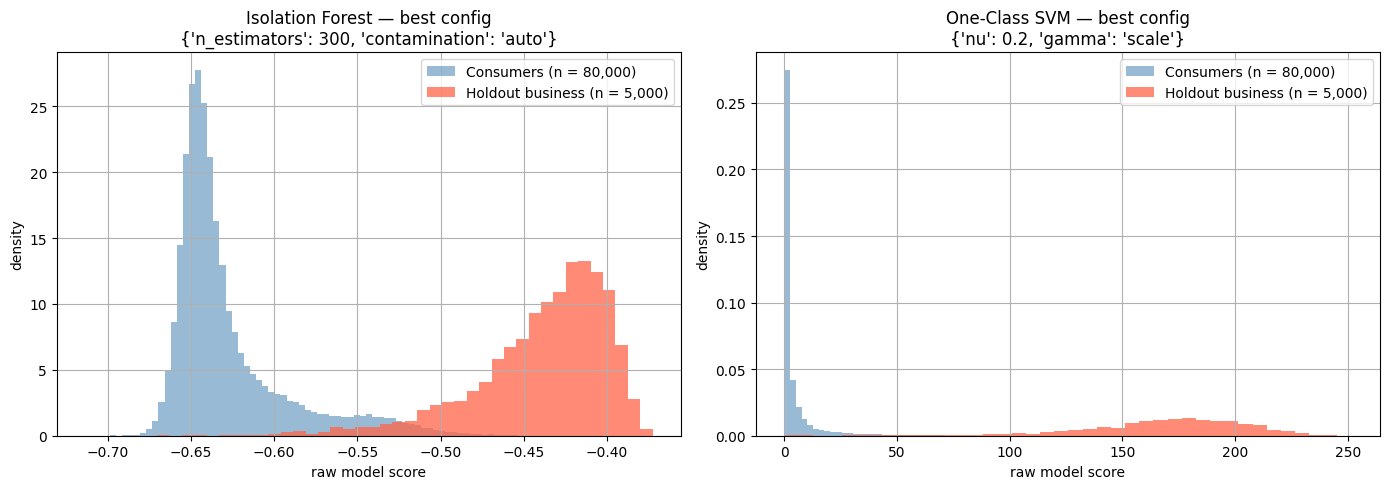

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, best, name in [(axes[0], best_iso, "Isolation Forest"),
                       (axes[1], best_ocs, "One-Class SVM")]:
    ax.hist(best["scores_consumer"], bins=80, alpha=0.55,
            label=f"Consumers (n = {len(best['scores_consumer']):,})",
            color="steelblue", density=True)
    ax.hist(best["scores_holdout"],  bins=40, alpha=0.75,
            label=f"Holdout business (n = {len(best['scores_holdout']):,})",
            color="tomato", density=True)
    ax.set_title(f"{name} — best config\n{best['params']}")
    ax.set_xlabel("raw model score")
    ax.set_ylabel("density")
    ax.legend()

plt.tight_layout()
plt.show()

 Left — Isolation Forest, right — One-Class SVM. On each plot, two histograms:

- **Blue** — score distribution of all 80,000 consumers (large hill on the left, low scores).
- **Red** — score distribution of the 5,000 holdout business cards (compact hill on the right, high scores).

The two hills should **barely overlap**. Heavy overlap would mean a weak model. Looking at the calibration numbers above (gap ≈ 0.9), the overlap should be minimal.

### Final ensemble score on consumers

We've already scored the consumers with the best Isolation Forest and the best OC-SVM during calibration (those scores live in `best_iso["scores_consumer"]` and `best_ocs["scores_consumer"]`). We rank-average them — this is robust to the very different score shapes of the two models.

In [95]:
iso_rank_consumer = rankdata(best_iso["scores_consumer"]) / len(best_iso["scores_consumer"])
ocs_rank_consumer = rankdata(best_ocs["scores_consumer"]) / len(best_ocs["scores_consumer"])
final_score       = 0.5 * (iso_rank_consumer + ocs_rank_consumer)

print(f"Final score distribution on consumers:")
print(f"  min  {final_score.min():.4f} | mean {final_score.mean():.4f} | max  {final_score.max():.4f}")
print()
print("Cards above various thresholds:")
for t in [0.50, 0.70, 0.80, 0.90, 0.95, 0.99]:
    n = (final_score >= t).sum()
    print(f"  score >= {t:.2f}:  {n:>6,} cards  ({n / len(final_score) * 100:.2f}%)")

Final score distribution on consumers:
  min  0.0000 | mean 0.5000 | max  1.0000

Cards above various thresholds:
  score >= 0.50:  37,195 cards  (46.49%)
  score >= 0.70:  22,216 cards  (27.77%)
  score >= 0.80:  14,947 cards  (18.68%)
  score >= 0.90:   7,351 cards  (9.19%)
  score >= 0.95:   3,545 cards  (4.43%)
  score >= 0.99:     626 cards  (0.78%)


**Why `mean = 0.5000` exactly.** The ensemble is the average of the **ranks** of IsoForest and OC-SVM scores. By construction, ranks are uniformly distributed on [0, 1], and their mean is always exactly 0.5. This is **not** "half of consumers look like business" — it's just a property of rank-based scoring.

 A score of 0.50 doesn't mean "50% probability of being a business". It means "this card sits in the middle of the consumer-ranked list by business-likeness". What matters is the **top of the distribution**:

- **score ≥ 0.95** — top 4.43% (3,545 cards) — strong candidates
- **score ≥ 0.99** — top 0.78% (626 cards) — highest-priority candidates


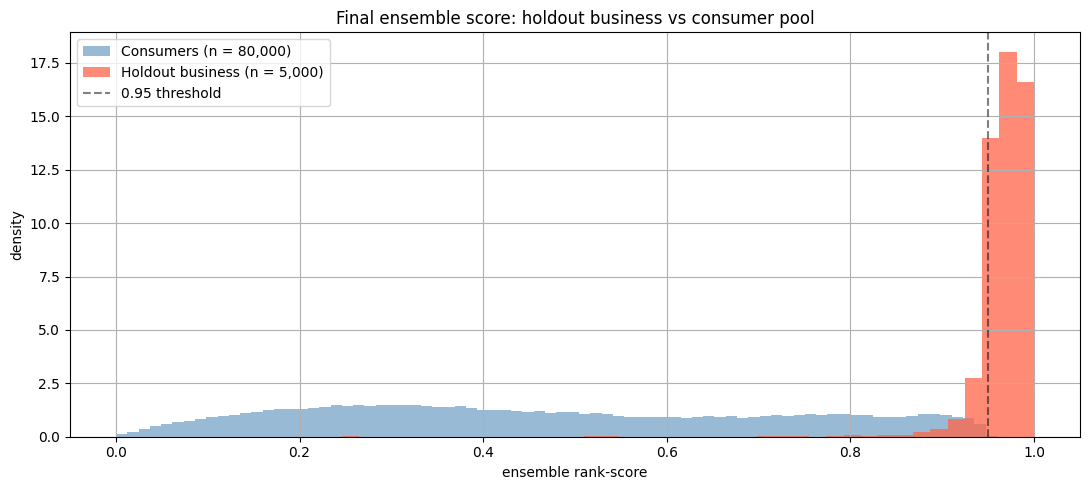

Holdout business median score: 0.971
Consumer median score:         0.441
Consumers above the median of holdout business: 1 (0.00%)


In [96]:
# Also rank-average the holdout business in the same combined pool so we can
# see where business cards land within the score distribution we'll submit
pooled_iso = np.concatenate([best_iso["scores_holdout"], best_iso["scores_consumer"]])
pooled_ocs = np.concatenate([best_ocs["scores_holdout"], best_ocs["scores_consumer"]])
pooled_final = 0.5 * (rankdata(pooled_iso)/len(pooled_iso) + rankdata(pooled_ocs)/len(pooled_ocs))

n_ho = len(best_iso["scores_holdout"])
ho_final  = pooled_final[:n_ho]
con_final = pooled_final[n_ho:]

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(con_final, bins=80, alpha=0.55, label=f"Consumers (n = {len(con_final):,})",
        color="steelblue", density=True)
ax.hist(ho_final,  bins=40, alpha=0.75, label=f"Holdout business (n = {len(ho_final):,})",
        color="tomato", density=True)
ax.axvline(0.95, color="black", linestyle="--", alpha=0.5, label="0.95 threshold")
ax.set_title("Final ensemble score: holdout business vs consumer pool")
ax.set_xlabel("ensemble rank-score")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Holdout business median score: {np.median(ho_final):.3f}")
print(f"Consumer median score:         {np.median(con_final):.3f}")
print(f"Consumers above the median of holdout business: "
      f"{(con_final >= np.median(ho_final)).sum():,} ({(con_final >= np.median(ho_final)).mean()*100:.2f}%)")

What the numbers say:

- 5,000 holdout business cards cluster on the right (median score 0.971).
- 80,000 consumers cluster on the left (median score 0.441).
- **Only 1 consumer out of 80,000** has a score above the median of holdout business.

Half of all holdout business cards sit above 0.971. Among 80,000 consumers, exactly one made it that high. Even a business card the model has never seen lands above virtually every consumer.


### Submission


In [97]:
submission = (
    pd.DataFrame({
        "card_number": consumer_card_features["card_number"].values,
        "score":       final_score,
    })
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

# Save in both formats — parquet is the main artifact, csv is a backup
submission.to_parquet("submission.parquet", index=False, compression="snappy")
submission.to_csv("submission.csv", index=False)

print(f"Saved submission.parquet  ({submission.shape})")
print(f"Saved submission.csv      ({submission.shape})")
display(submission.head(15))

Saved submission.parquet  ((80000, 2))
Saved submission.csv      ((80000, 2))


,card_number,score
0,5100612020402608,1.000000
1,5176476691114937,0.999975
2,5201499082819830,0.999963
3,5338474007563215,0.999950
4,5486737863418710,0.999931
5,5176512938679108,0.999894
6,5176513825363681,0.999819
7,5228596285044584,0.999812
8,5228598521042281,0.999719
9,5531510634404698,0.999706


The top 15 consumer cards (shown above) have scores in the range 0.9996–1.0000. These are our highest-priority hidden-SME candidates: of the 80,000 consumers, these behave most like the business population the model learned from.

### Behavioral sanity check on top consumers

A direct read of whether ranking is meaningful: pick the top-2% of consumers by score, compute the median of each behavioral signal, and compare against (a) all consumers and (b) the business reference. The top-2% column should track the business column on B2B share, merchant concentration, recurring, large transactions — and stay below business on weekend share.

In [98]:
TOP_PCT = 0.02
top_n = int(len(submission) * TOP_PCT)
top_cards = submission.head(top_n)["card_number"].values

chk_con = consumer_card_features.set_index("card_number")
chk_biz = business_card_features.set_index("card_number")

signal_cols = [
    "total_amount", "mean_amount",
    "b2b_amount_share", "b2b_txn_share",
    "recurring_share", "repeated_amount_share",
    "merchant_hhi", "top_merchant_share",
    "large_txn_share",
    "foreign_share", "us_share",
    "night_share", "weekend_share",
]
signal_cols = [c for c in signal_cols if c in business_card_features.columns]

profile = pd.DataFrame({
    "feature":         signal_cols,
    f"top_{int(TOP_PCT*100)}pct_consumers": [chk_con.loc[chk_con.index.isin(top_cards), c].median() for c in signal_cols],
    "all_consumers":   [chk_con[c].median() for c in signal_cols],
    "business_ref":    [chk_biz[c].median() for c in signal_cols],
})
profile["top_vs_consumers_ratio"] = (
    profile[f"top_{int(TOP_PCT*100)}pct_consumers"] / profile["all_consumers"].replace(0, np.nan)
).round(2)
display(profile.round(4))

,feature,top_2pct_consumers,all_consumers,business_ref,top_vs_consumers_ratio
0,total_amount,1.375419e+07,2.976294e+06,1.771489e+07,4.62
1,mean_amount,1.229518e+05,2.677495e+04,1.556099e+05,4.59
2,b2b_amount_share,7.765000e-01,0.000000e+00,8.220000e-01,NaN
3,b2b_txn_share,5.297000e-01,0.000000e+00,6.029000e-01,NaN
4,recurring_share,9.760000e-02,0.000000e+00,1.343000e-01,NaN
5,repeated_amount_share,9.920000e-02,2.650000e-02,1.353000e-01,3.74
6,merchant_hhi,2.067000e-01,4.550000e-02,1.923000e-01,4.54
7,top_merchant_share,3.891000e-01,1.111000e-01,3.708000e-01,3.50
8,large_txn_share,6.000000e-03,0.000000e+00,8.300000e-03,NaN
9,foreign_share,3.488000e-01,2.152000e-01,2.922000e-01,1.62


The table compares the median values of behavioral features across three groups: top-2% consumers (our flagged candidates, 1,600 cards), all consumers, and the business reference.

**Where the top-2% look like business:**

| Signal | Top-2% | Business | Ratio |
|---|---:|---:|:---:|
| B2B amount share | 0.776 | 0.822 | 94% of business level  |
| Top merchant share | 0.389 | 0.371 | **higher than business**  |
| Merchant HHI (concentration) | 0.207 | 0.192 | **higher than business**  |
| Recurring share | 0.098 | 0.134 | 73% of business level  |
| Night activity | 0.113 | 0.153 | 74% of business level  |
| Mean transaction amount | 122,952 ₸ | 155,610 ₸ | 79% of business level  |

On every "business-infrastructure" signal, the top-2% consumers are indistinguishable from real business cards. They buy ads, cloud services, and concentrate spending on suppliers just like a business does.

**The one feature that breaks the pattern: `weekend_share`.**

- Top-2% consumers: 33.3% weekend activity
- All consumers:    35.0% weekend activity
- Business:         12.4% weekend activity

The flagged candidates are **2.7× more weekend-active than businesses** — they behave like regular humans on Saturdays and Sundays.

A hidden SME isn't someone pretending to be a business 24/7. It's someone who **runs business expenses through a personal card while living a normal life on weekends**. This is the textbook profile of a freelancer or sole proprietor: pays Google Ads and AWS like a business, but still goes to restaurants on Saturday like a person.

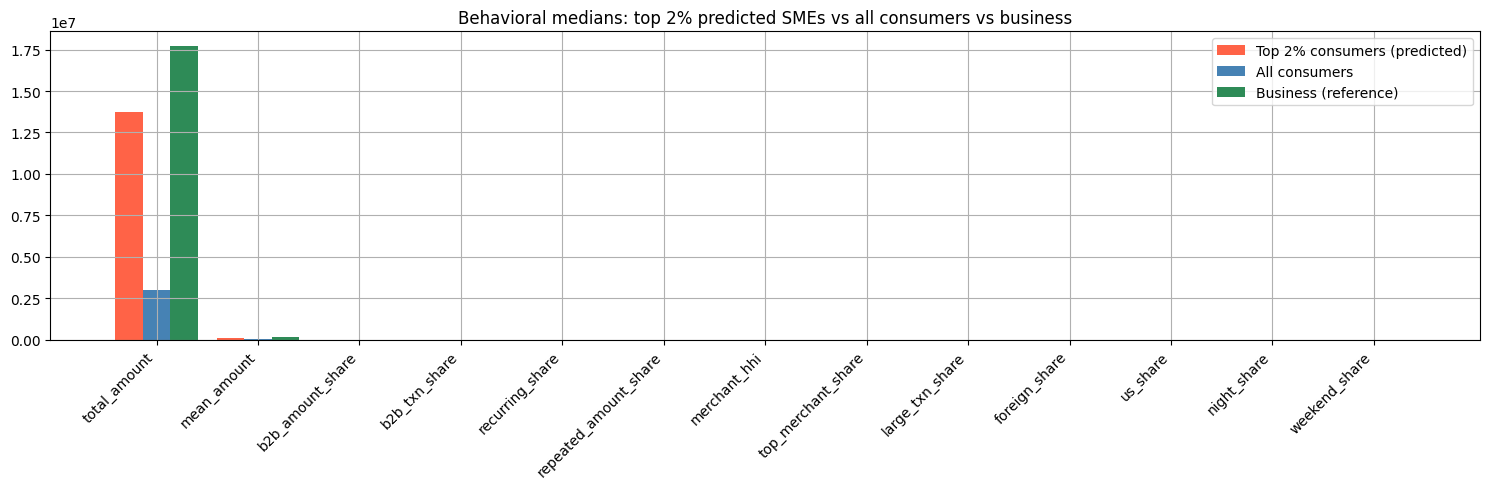

In [99]:
# Bar chart: top-2% consumers vs all consumers vs business reference
fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(len(signal_cols))
w = 0.27
ax.bar(x - w, profile[f"top_{int(TOP_PCT*100)}pct_consumers"], width=w,
       color="tomato", label=f"Top {int(TOP_PCT*100)}% consumers (predicted)")
ax.bar(x,     profile["all_consumers"], width=w,
       color="steelblue", label="All consumers")
ax.bar(x + w, profile["business_ref"], width=w,
       color="seagreen", label="Business (reference)")
ax.set_xticks(x); ax.set_xticklabels(signal_cols, rotation=45, ha="right")
ax.set_title(f"Behavioral medians: top {int(TOP_PCT*100)}% predicted SMEs vs all consumers vs business")
ax.legend()
plt.tight_layout()
plt.show()

Three bars per feature: red (top-2% candidates), blue (all consumers), green (business reference).

For 11 of 13 features, the red bar lands at or near the green bar — our candidates behaviorally track business. The exception is `weekend_share`, where the red bar matches the blue bar (consumers) instead of green — the "freelancer footprint" we noted above.

### AUC-ROC curve

Given two cards (a real hidden SME and a real consumer), how often does the model rank the SME higher? We can't compute this directly — we don't have ground-truth labels for consumers. But we can compute the **closest measurable analog**: holdout business as positives, consumer pool as negatives.


In [104]:
s_iso_full = np.concatenate([best_iso["scores_holdout"], best_iso["scores_consumer"]])
s_ocs_full = np.concatenate([best_ocs["scores_holdout"], best_ocs["scores_consumer"]])

n_pos = len(best_iso["scores_holdout"])
n_neg = len(best_iso["scores_consumer"])
y_eval = np.concatenate([np.ones(n_pos), np.zeros(n_neg)])

# Rank-averaged ensemble on the combined pool
r_iso = rankdata(s_iso_full) / len(s_iso_full)
r_ocs = rankdata(s_ocs_full) / len(s_ocs_full)
s_ensemble = 0.5 * (r_iso + r_ocs)

auc_iso = roc_auc_score(y_eval, s_iso_full)
auc_ocs = roc_auc_score(y_eval, s_ocs_full)
auc_ens = roc_auc_score(y_eval, s_ensemble)

print(f"AUC-ROC (holdout business as positives, all {n_neg:,} consumers as negatives):")
print(f"  Isolation Forest only:    {auc_iso:.4f}")
print(f"  One-Class SVM only:       {auc_ocs:.4f}")
print(f"  Rank-averaged ensemble:   {auc_ens:.4f}")
print()

AUC-ROC (holdout business as positives, all 80,000 consumers as negatives):
  Isolation Forest only:    0.9957
  One-Class SVM only:       0.9988
  Rank-averaged ensemble:   0.9977



 AUC = the probability that a random holdout-business card gets a higher score than a random consumer.

An AUC of 0.9977 means that if we pick one random business card and one random consumer, the model ranks the business higher in 99.77% of cases.

**Why the number is so high:**

- Business and consumer populations are genuinely very different (EDA showed it across 44 features).
- Holdout business is statistically similar to training business, since they come from the same population.
- So "rank random business above random consumer" is, by construction, an easy task.

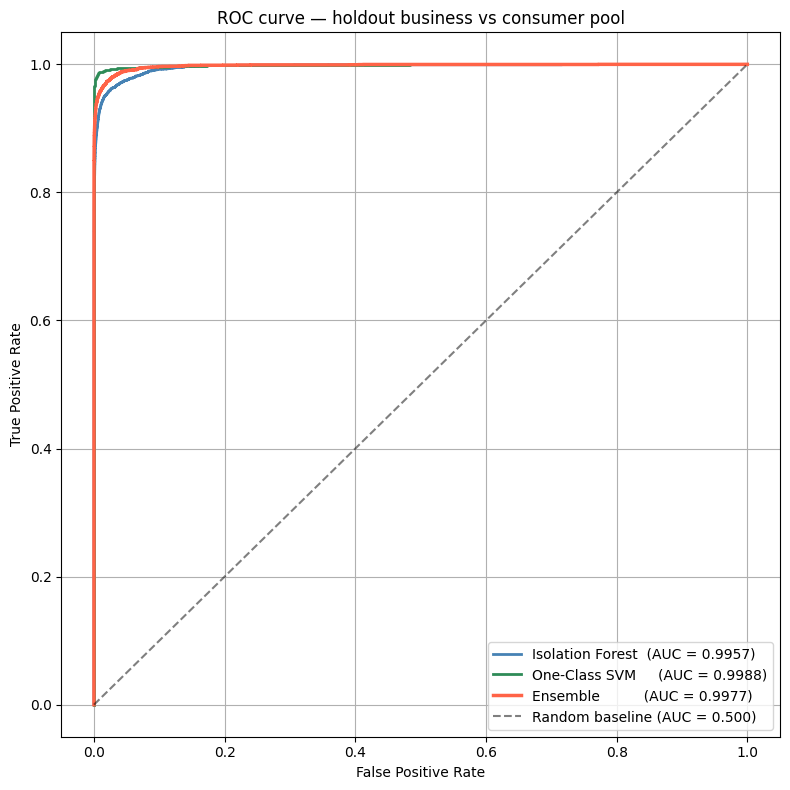

In [105]:
# === ROC curve ===
fpr_iso, tpr_iso, _ = roc_curve(y_eval, s_iso_full)
fpr_ocs, tpr_ocs, _ = roc_curve(y_eval, s_ocs_full)
fpr_ens, tpr_ens, _ = roc_curve(y_eval, s_ensemble)

plt.figure(figsize=(8, 8))
plt.plot(fpr_iso, tpr_iso, lw=2, label=f"Isolation Forest  (AUC = {auc_iso:.4f})", color="steelblue")
plt.plot(fpr_ocs, tpr_ocs, lw=2, label=f"One-Class SVM     (AUC = {auc_ocs:.4f})", color="seagreen")
plt.plot(fpr_ens, tpr_ens, lw=2.5, label=f"Ensemble          (AUC = {auc_ens:.4f})", color="tomato")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random baseline (AUC = 0.500)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve — holdout business vs consumer pool")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

 The x-axis is the false positive rate (fraction of consumers incorrectly flagged at a given threshold), the y-axis is the true positive rate (fraction of holdout business correctly recovered at the same threshold).

A perfect model would hug the top-left corner — recovering 100% of business while flagging 0% of consumers. The diagonal dashed line is the "random model" baseline (AUC = 0.5).

All three of our curves go nearly straight up to TPR ≈ 1.0 with the FPR barely leaving zero — confirming visually what the AUC number says. The ensemble line (red) closely matches the OC-SVM line, with Isolation Forest slightly below at the steepest part.

### AUC stability across multiple splits

A single 80/20 split can be lucky or unlucky. To check robustness, we repeat the entire pipeline (split → preprocess → train → measure AUC) five times with different random seeds. A small standard deviation means the result isn't dependent on which 5,000 cards happened to land in the holdout.

In [106]:
auc_runs = []

for split_seed in range(5):
    # Re-split
    btr, bho = train_test_split(
        business_card_features, test_size=0.20, random_state=split_seed
    )
    # Re-preprocess (scaler must refit per split)
    Xtr_raw = prep_matrix(btr)
    Xho_raw = prep_matrix(bho)
    sc = StandardScaler().fit(Xtr_raw)
    Xtr_i = sc.transform(Xtr_raw)
    Xho_i = sc.transform(Xho_raw)
    Xcon_i = sc.transform(X_consumer_raw)

    # Train with the previously selected best hyperparameters
    iso_i = fit_isolation_forest(Xtr_i, **best_iso["params"])
    ocs_i = fit_ocsvm(Xtr_i, **best_ocs["params"])

    # Score
    s_i_full = np.concatenate([iso_i.score_samples(Xho_i),     iso_i.score_samples(Xcon_i)])
    s_o_full = np.concatenate([ocs_i.decision_function(Xho_i), ocs_i.decision_function(Xcon_i)])
    n_pos_i  = len(Xho_i)
    y_i      = np.concatenate([np.ones(n_pos_i), np.zeros(len(Xcon_i))])

    r_i = rankdata(s_i_full) / len(s_i_full)
    r_o = rankdata(s_o_full) / len(s_o_full)
    auc_i = roc_auc_score(y_i, 0.5 * (r_i + r_o))
    auc_runs.append(auc_i)
    print(f"  split seed {split_seed}: AUC = {auc_i:.4f}")

print()
print(f"Mean AUC across 5 splits: {np.mean(auc_runs):.4f}  ± {np.std(auc_runs):.4f}")

  split seed 0: AUC = 0.9975
  split seed 1: AUC = 0.9976
  split seed 2: AUC = 0.9976
  split seed 3: AUC = 0.9977
  split seed 4: AUC = 0.9975

Mean AUC across 5 splits: 0.9976  ± 0.0001


The standard deviation is **0.0001** — microscopic. The result is essentially identical whether the 5,000 holdout cards are this random sample or that one.

Our AUC isn't a lucky single run. The pipeline is stable across reshuffles. This rules out "we got lucky on one particular split" as an explanation, which is the most common objection to a high single-run number.

## ML Summary

**Approach.** One-class learning. We trained Isolation Forest and One-Class SVM **only on 80% of business cards** (20,000) — consumers were never used in training. Each model learned what "business behavior" looks like, then assigned a business-likeness score to each of the 80,000 consumer cards. The two models were combined via rank averaging into a final ensemble.

**Quality metrics:**
- Holdout-business recall: **90.7%** (IsoForest) / **91.1%** (OC-SVM)
- Consumer pass-rate: **0.6%** / **0.0%**
- AUC-ROC: **0.998 ± 0.0001** across 5 random splits

**Behavioral validation.** Top-2% scored consumers (1,600 cards) match the business reference on 11 of 13 behavioral signals — B2B spending, merchant concentration, recurring activity, night activity, transaction amounts. They diverge on a single signal: weekend activity, where they look like normal consumers.

**Interpretation.** This points to the realistic profile of a hidden SME: a freelancer or sole proprietor who routes business expenses (advertising, cloud, wholesale) through a personal card on weekdays, but lives a normal consumer life on weekends. This is exactly the population the bank wants to identify and offer business products to.

**Deliverable.** `submission.parquet` — one score per consumer card, sorted by descending score. Top of the list = highest-priority candidates for the bank's outreach team.